# YOLOv8n 十类手势检测：从数据准备到推理

本 Notebook 使用项目中的 `yolov8n.pt` 和 HaGRID 子集，完整演示目标检测训练流程：

1. 检查环境和原始标注；
2. 选择 10 类手势和部分图片；
3. 按 `user_id` 划分 train/val/test，避免同一个人的图片泄漏到不同集合；
4. 转换成 Ultralytics YOLO 标签格式；
5. 展示标签文件和可视化检测框；
6. 用 2 个 epoch 做冒烟测试；
7. 使用较大的子集进行 CPU 正式训练；
8. 在验证集、测试集上评估，并对留出的测试图片做最终推理。

这次 Demo 使用 10 个类别，每类最多 50 张正样本，另取 80 张 `no_gesture` 背景图，
总量约 580 张。与之前的 5 类、每类 30 张相比，样本量增加后更适合观察类别之间的
区分效果，同时仍然控制在 CPU 可以接受的训练规模内。

类别编号固定为：

| ID | 类别 |
|---:|---|
| 0 | fist |
| 1 | stop |
| 2 | peace |
| 3 | ok |
| 4 | like |
| 5 | one |
| 6 | four |
| 7 | palm |
| 8 | call |
| 9 | rock |

注意：`no_gesture` 不是第 11 个类别，而是空标签背景图，用于帮助模型学习“这里没有手势目标”。


In [1]:
from pathlib import Path
import json
import random
import shutil
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

from IPython.display import display, Image as IPyImage

import torch
import ultralytics
from ultralytics import YOLO


ROOT = Path("/home/xx/gesture-training")

RAW_DIR = ROOT / "data" / "raw" / "hagrid-export_100_images"
ANNOTATION_PATH = RAW_DIR / "annotations.json"
MODEL_PATH = ROOT / "yolov8n.pt"

# 10 类版本使用独立目录，不覆盖已经验证过的 gesture5_demo。
DATASET_DIR = ROOT / "data" / "yolo" / "gesture10_demo"
RUN_DIR = ROOT / "runs" / "ultralytics"

SEED = 42

CLASS_NAMES = [
    "fist",
    "stop",
    "peace",
    "ok",
    "like",
    "one",
    "four",
    "palm",
    "call",
    "rock",
]

CLASS_TO_ID = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

# 每类 50 张正样本，共约 500 张；背景图 80 张。
MAX_PER_CLASS = 50
MAX_BACKGROUND = 80

print("ROOT:", ROOT)
print("torch:", torch.__version__)
print("ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())
print("model exists:", MODEL_PATH.exists())
print("annotation exists:", ANNOTATION_PATH.exists())

assert ROOT.exists()
assert ANNOTATION_PATH.exists()
assert MODEL_PATH.exists()
assert len(CLASS_NAMES) == 10


ROOT: /home/xx/gesture-training
torch: 2.10.0+cu128
ultralytics: 8.4.146
CUDA available: False
model exists: True
annotation exists: True


## 1. 查看原始数据集

完整的 `annotations.json` 同时包含图片标签、边界框和 `user_id`。

这里使用完整标注文件而不是 `minimal-annotations.json`，原因是后面要按人员划分数据集。
如果同一个人的图片同时进入训练集和测试集，测试指标会偏乐观。


In [2]:
with ANNOTATION_PATH.open("r", encoding="utf-8") as f:
    annotations = json.load(f)

available_classes = [
    name
    for name, items in annotations.items()
    if name != "no_gesture"
    and not name.endswith("-checkpoint")
    and len(items) > 0
]

class_summary = pd.DataFrame(
    [
        {
            "class": name,
            "annotation_count": len(annotations[name]),
            "image_count": len(list((RAW_DIR / name).glob("*.jpg"))),
            "users": len({item["user_id"] for item in annotations[name].values()}),
        }
        for name in available_classes
    ]
).sort_values("class")

display(class_summary)

print("Selected classes:", CLASS_NAMES)
print("Background images:", len(annotations["no_gesture"]))

# 检查所选类别是否都存在于当前数据中。
missing_classes = [
    name
    for name in CLASS_NAMES
    if name not in annotations or not annotations[name]
]
assert not missing_classes, f"Missing classes: {missing_classes}"


,class,annotation_count,image_count,users
16,call,100,100,98
7,dislike,100,100,99
15,fist,100,100,97
8,four,100,100,98
27,grabbing,100,100,93
23,grip,100,100,95
26,hand_heart,100,100,95
30,hand_heart2,100,100,94
31,holy,100,100,97
17,like,100,100,100


Selected classes: ['fist', 'stop', 'peace', 'ok', 'like', 'one', 'four', 'palm', 'call', 'rock']
Background images: 91


## 2. 选择图片并转换成 YOLO 数据集

原始 HaGRID 框是归一化的左上角坐标：

```text
[x_left, y_top, width, height]
```

YOLO 检测标签是一行一个目标：

```text
class_id center_x center_y width height
```

坐标仍然归一化到 `0~1`，但中心点需要由左上角坐标计算得到。

数据划分比例为 train/val/test = 70%/15%/15%，划分单位是 `user_id`，不是单张图片。

本 Cell 执行后才会创建 `data/yolo/gesture10_demo`。如果修改了采样参数并重新运行，
请把 `DATASET_DIR` 改成一个新的目录名，避免旧标签混入。


In [3]:
def convert_box_to_yolo(box):
    # 原始格式：左上角 x、左上角 y、宽、高
    x, y, width, height = map(float, box)

    # 先将输入限制在合法归一化范围内。
    x = max(0.0, min(1.0, x))
    y = max(0.0, min(1.0, y))
    width = max(0.0, min(1.0 - x, width))
    height = max(0.0, min(1.0 - y, height))

    center_x = x + width / 2.0
    center_y = y + height / 2.0

    return center_x, center_y, width, height


if DATASET_DIR.exists():
    raise RuntimeError(
        f"{DATASET_DIR} 已经存在。请把 DATASET_DIR 改成新的目录名，"
        "避免旧数据混入。"
    )


rng = random.Random(SEED)
samples = []
seen_paths = set()


# 为每个正样本类别随机选取最多 MAX_PER_CLASS 张图片。
for class_name in CLASS_NAMES:
    candidates = []

    for image_id, item in annotations[class_name].items():
        image_path = RAW_DIR / class_name / f"{image_id}.jpg"
        labels = item.get("labels", [])
        bboxes = item.get("bboxes", [])

        if not image_path.exists():
            continue
        if not labels:
            continue
        if not set(labels).issubset(set(CLASS_NAMES)):
            continue
        if len(labels) != len(bboxes):
            continue
        if image_path in seen_paths:
            continue

        yolo_labels = []

        for label, bbox in zip(labels, bboxes):
            class_id = CLASS_TO_ID[label]
            center_x, center_y, width, height = convert_box_to_yolo(bbox)

            if width <= 0.0 or height <= 0.0:
                continue

            yolo_labels.append(
                (class_id, center_x, center_y, width, height)
            )

        if not yolo_labels:
            continue

        candidates.append(
            {
                "image_id": image_id,
                "source_class": class_name,
                "image_path": image_path,
                "user_id": item["user_id"],
                "yolo_labels": yolo_labels,
            }
        )

    rng.shuffle(candidates)

    for sample in candidates[:MAX_PER_CLASS]:
        samples.append(sample)
        seen_paths.add(sample["image_path"])


# no_gesture 是背景图，标签文件必须为空，而不是写成第 11 类。
background_candidates = []

for image_id, item in annotations["no_gesture"].items():
    image_path = RAW_DIR / "no_gesture" / f"{image_id}.jpg"

    if image_path.exists():
        background_candidates.append(
            {
                "image_id": image_id,
                "source_class": "no_gesture",
                "image_path": image_path,
                "user_id": item["user_id"],
                "yolo_labels": [],
            }
        )

rng.shuffle(background_candidates)
samples.extend(background_candidates[:MAX_BACKGROUND])


# 按人员划分数据集。
users = sorted({sample["user_id"] for sample in samples})
rng.shuffle(users)

train_end = int(len(users) * 0.70)
val_end = train_end + int(len(users) * 0.15)

train_users = set(users[:train_end])
val_users = set(users[train_end:val_end])
test_users = set(users[val_end:])

for sample in samples:
    if sample["user_id"] in train_users:
        sample["split"] = "train"
    elif sample["user_id"] in val_users:
        sample["split"] = "val"
    elif sample["user_id"] in test_users:
        sample["split"] = "test"
    else:
        raise RuntimeError("Unknown user split")


print("Total selected images:", len(samples))
print("Images by source:", Counter(sample["source_class"] for sample in samples))
print(
    "Users by split:",
    {
        "train": len(train_users),
        "val": len(val_users),
        "test": len(test_users),
    },
)
print("Images by split:", Counter(sample["split"] for sample in samples))


# 创建 images/{train,val,test} 和 labels/{train,val,test}。
for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True)


# 复制图片，生成对应的 YOLO txt 文件。
for sample in samples:
    split = sample["split"]
    filename = f"{sample['source_class']}_{sample['image_id']}.jpg"

    image_destination = DATASET_DIR / "images" / split / filename
    label_destination = (
        DATASET_DIR / "labels" / split / filename.replace(".jpg", ".txt")
    )

    shutil.copy2(sample["image_path"], image_destination)

    label_lines = [
        f"{class_id} {center_x:.8f} {center_y:.8f} "
        f"{width:.8f} {height:.8f}"
        for class_id, center_x, center_y, width, height
        in sample["yolo_labels"]
    ]

    # 背景图这里会写入空文件，这是 YOLO 合法的背景样本表示方式。
    label_destination.write_text(
        "\n".join(label_lines) + ("\n" if label_lines else ""),
        encoding="utf-8",
    )


names_text = ", ".join(f"'{name}'" for name in CLASS_NAMES)
yaml_text = (
    f"path: '{DATASET_DIR.as_posix()}'\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n"
    f"names: [{names_text}]\n"
)

DATA_YAML = DATASET_DIR / "data.yaml"
DATA_YAML.write_text(yaml_text, encoding="utf-8")

print("\nCreated dataset:", DATASET_DIR)
print(DATA_YAML.read_text(encoding="utf-8"))


Total selected images: 580
Images by source: Counter({'no_gesture': 80, 'fist': 50, 'stop': 50, 'peace': 50, 'ok': 50, 'like': 50, 'one': 50, 'four': 50, 'palm': 50, 'call': 50, 'rock': 50})
Users by split: {'train': 370, 'val': 79, 'test': 80}
Images by split: Counter({'train': 403, 'test': 90, 'val': 87})

Created dataset: /home/xx/gesture-training/data/yolo/gesture10_demo
path: '/home/xx/gesture-training/data/yolo/gesture10_demo'
train: images/train
val: images/val
test: images/test
names: ['fist', 'stop', 'peace', 'ok', 'like', 'one', 'four', 'palm', 'call', 'rock']



## 3. 检查数据集和标签完整性

每张图片都应该有一个同名 `.txt` 文件。正样本的标签文件包含目标框，
`no_gesture` 背景图的标签文件为空。

同时检查以下约束：

- 类别编号必须在 `0~9`；
- 坐标必须在 `0~1`；
- 框的宽高必须大于 0；
- 不能存在缺失标签或多余标签。


In [4]:
def validate_yolo_dataset(dataset_dir):
    rows = []
    invalid_lines = []

    for split in ["train", "val", "test"]:
        image_dir = dataset_dir / "images" / split
        label_dir = dataset_dir / "labels" / split

        image_paths = sorted(image_dir.glob("*.jpg"))
        label_paths = sorted(label_dir.glob("*.txt"))

        image_stems = {path.stem for path in image_paths}
        label_stems = {path.stem for path in label_paths}

        missing_labels = image_stems - label_stems
        orphan_labels = label_stems - image_stems

        class_counter = Counter()
        object_count = 0

        for label_path in label_paths:
            text = label_path.read_text(encoding="utf-8").strip()

            # 空文件代表背景图，是合法情况。
            if not text:
                continue

            for line_number, line in enumerate(text.splitlines(), start=1):
                parts = line.split()

                if len(parts) != 5:
                    invalid_lines.append(
                        (label_path, line_number, line, "field_count")
                    )
                    continue

                try:
                    class_id = int(parts[0])
                    values = [float(value) for value in parts[1:]]
                except ValueError:
                    invalid_lines.append(
                        (label_path, line_number, line, "not_numeric")
                    )
                    continue

                if not 0 <= class_id < len(CLASS_NAMES):
                    invalid_lines.append(
                        (label_path, line_number, line, "invalid_class_id")
                    )

                if not all(0.0 <= value <= 1.0 for value in values):
                    invalid_lines.append(
                        (label_path, line_number, line, "coordinate_range")
                    )

                if values[2] <= 0.0 or values[3] <= 0.0:
                    invalid_lines.append(
                        (label_path, line_number, line, "invalid_box_size")
                    )

                if 0 <= class_id < len(CLASS_NAMES):
                    class_counter[CLASS_NAMES[class_id]] += 1

                object_count += 1

        rows.append(
            {
                "split": split,
                "images": len(image_paths),
                "label_files": len(label_paths),
                "objects": object_count,
                "missing_labels": len(missing_labels),
                "orphan_labels": len(orphan_labels),
                **class_counter,
            }
        )

    if invalid_lines:
        print("Invalid label examples:")
        for item in invalid_lines[:5]:
            print(item)
    else:
        print("All YOLO label values are valid.")

    return pd.DataFrame(rows).fillna(0)


dataset_check = validate_yolo_dataset(DATASET_DIR)
display(dataset_check)

assert (dataset_check["missing_labels"] == 0).all()
assert (dataset_check["orphan_labels"] == 0).all()


All YOLO label values are valid.


,split,images,label_files,objects,missing_labels,orphan_labels,call,fist,four,like,ok,one,palm,peace,rock,stop
0,train,403,403,343,0,0,31,33,37,39,36,32,35,34,30,36
1,val,87,87,76,0,0,8,8,6,9,6,10,9,4,9,7
2,test,90,90,81,0,0,11,9,7,2,8,8,6,12,11,7


## 4. 查看标签文件内容

先直接打印一张正样本和一张背景图的标签文件。

正样本中每一行对应一个手势目标；背景图的 `.txt` 文件为空。
这是理解 YOLO 数据格式最直接的一步。


In [5]:
train_image_paths = sorted(
    (DATASET_DIR / "images" / "train").glob("*.jpg")
)

positive_image = None
background_image = None

for image_path in train_image_paths:
    label_path = (
        DATASET_DIR / "labels" / "train" /
        image_path.with_suffix(".txt").name
    )

    text = label_path.read_text(encoding="utf-8").strip()

    if text and positive_image is None:
        positive_image = image_path

    if not text and background_image is None:
        background_image = image_path

positive_label_path = (
    DATASET_DIR / "labels" / "train" /
    positive_image.with_suffix(".txt").name
)
background_label_path = (
    DATASET_DIR / "labels" / "train" /
    background_image.with_suffix(".txt").name
)

print("Positive image:", positive_image.name)
print("Positive label file:")
print(positive_label_path.read_text(encoding="utf-8"))

print("Background image:", background_image.name)
print("Background label file:")
print(background_label_path.read_text(encoding="utf-8") or "<empty>")


Positive image: call_140a88aa-58ba-4d88-8aba-5868a261cfd0.jpg
Positive label file:
8 0.64813765 0.55940126 0.28851277 0.22781930

Background image: no_gesture_04bf0f63-e41b-4015-afc6-398f7acee9db.jpg
Background label file:
<empty>


## 5. 可视化边界框

训练前必须确认框的位置和类别都正确。这里把 YOLO 的中心点格式还原成左上角格式，
再绘制到原图上。

如果框没有落在手上，优先检查坐标转换，而不是继续训练。


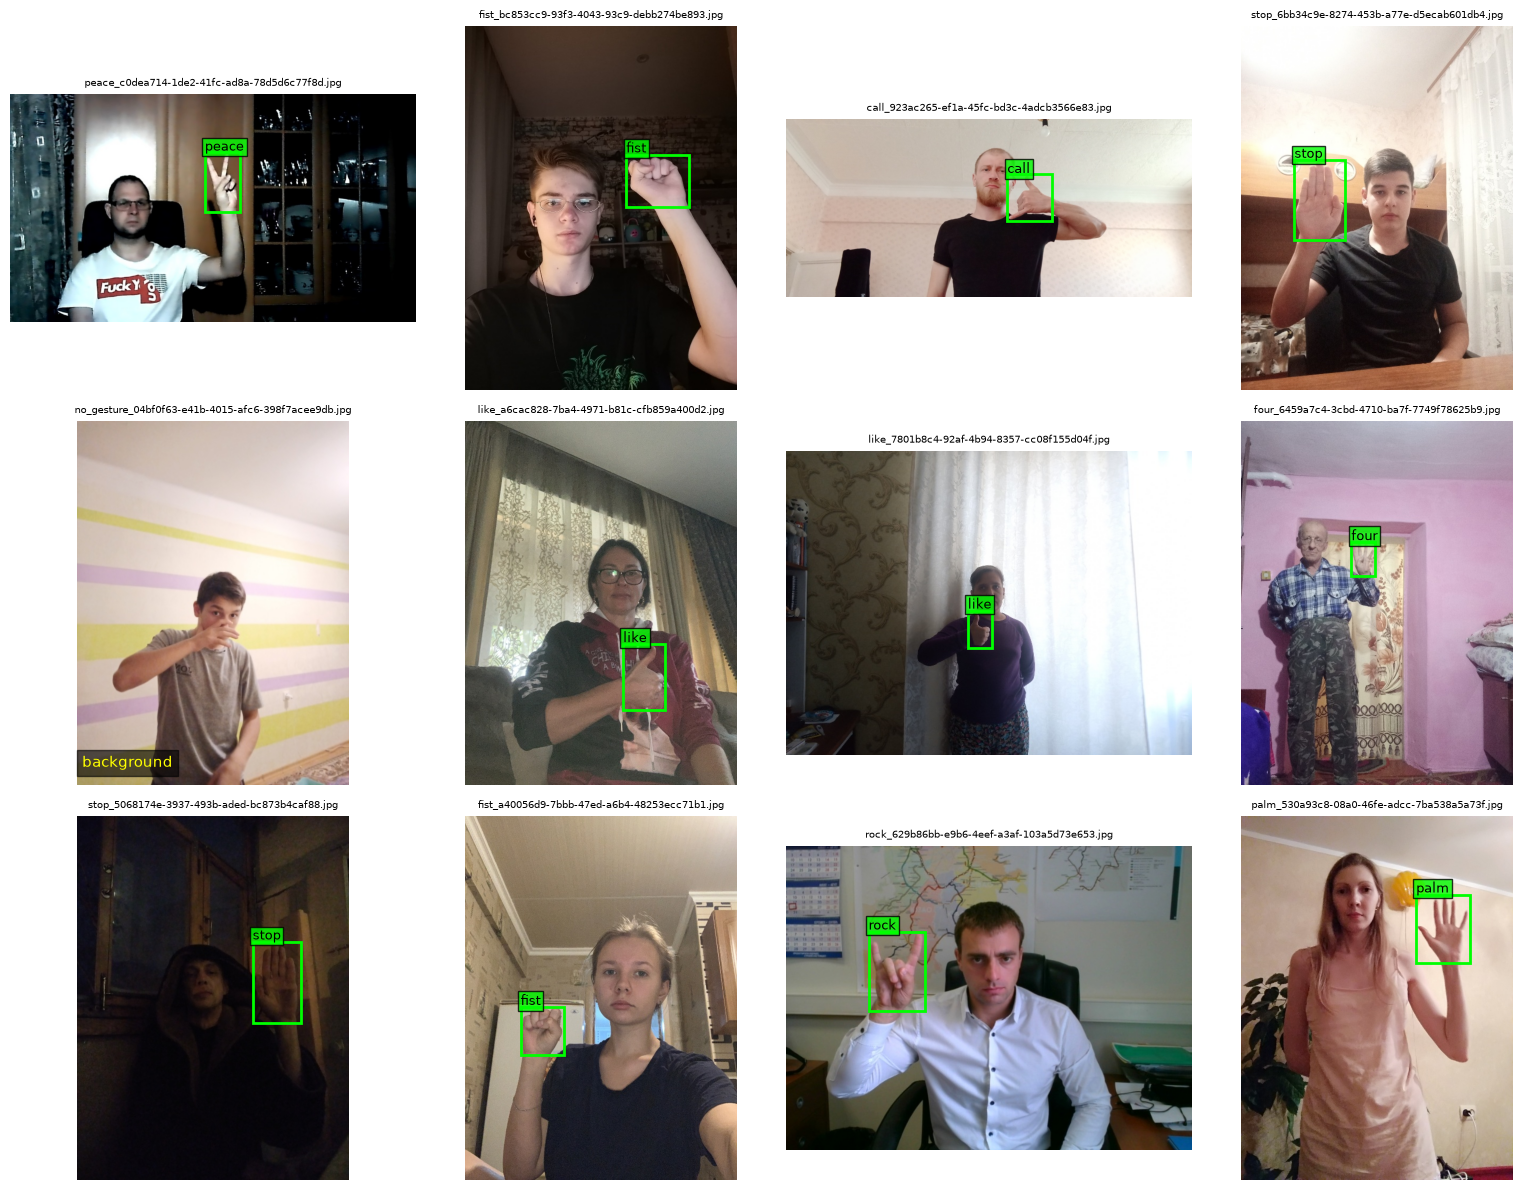

In [6]:
def show_yolo_samples(dataset_dir, split="train", count=12, seed=42):
    image_paths = sorted(
        (dataset_dir / "images" / split).glob("*.jpg")
    )

    rng = random.Random(seed)
    selected = rng.sample(image_paths, min(count, len(image_paths)))

    columns = 4
    rows = int(np.ceil(len(selected) / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, 4 * rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, image_path in zip(axes, selected):
        image = Image.open(image_path).convert("RGB")
        image_array = np.asarray(image)
        height, width = image_array.shape[:2]

        ax.imshow(image_array)
        ax.set_title(image_path.name, fontsize=7)
        ax.axis("off")

        label_path = (
            dataset_dir / "labels" / split /
            image_path.with_suffix(".txt").name
        )
        text = label_path.read_text(encoding="utf-8").strip()

        if not text:
            ax.text(
                0.02,
                0.05,
                "background",
                transform=ax.transAxes,
                color="yellow",
                fontsize=11,
                bbox={"facecolor": "black", "alpha": 0.6},
            )
            continue

        for line in text.splitlines():
            class_id, cx, cy, box_w, box_h = map(float, line.split())
            class_id = int(class_id)

            x1 = (cx - box_w / 2.0) * width
            y1 = (cy - box_h / 2.0) * height
            pixel_width = box_w * width
            pixel_height = box_h * height

            ax.add_patch(
                Rectangle(
                    (x1, y1),
                    pixel_width,
                    pixel_height,
                    linewidth=2,
                    edgecolor="lime",
                    facecolor="none",
                )
            )

            ax.text(
                x1,
                max(0, y1 - 4),
                CLASS_NAMES[class_id],
                color="black",
                fontsize=9,
                bbox={"facecolor": "lime", "alpha": 0.8, "pad": 2},
            )

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_yolo_samples(
    DATASET_DIR,
    split="train",
    count=12,
    seed=SEED,
)


## 6. 冒烟测试：只跑 2 个 epoch

冒烟测试用于确认训练链路可用，不用于判断模型精度。

参数说明：

| 参数 | 本次值 | 作用 |
|---|---:|---|
| `data` | `data.yaml` | 指定训练、验证、测试图片路径和类别名 |
| `imgsz` | 320 | 将输入缩放到 320×320，降低 CPU 计算量 |
| `epochs` | 2 | 快速确认训练能启动、验证能运行、权重能保存 |
| `batch` | 4 | 每次参数更新使用的图片数，CPU 下取保守值 |
| `workers` | 0 | Notebook 中不启用额外数据加载进程，避免进程问题 |
| `device` | `cpu` | 强制使用 CPU |
| `amp` | `False` | CPU 下关闭混合精度 |
| `cache` | `False` | 不把数据缓存到内存，降低内存占用 |
| `mosaic` | 0 | 冒烟测试减少增强，缩短验证路径 |

只要 Cell 正常结束，并生成 `last.pt`，就说明数据、模型、训练和保存流程基本没有问题。


In [7]:
SMOKE_NAME = "gesture10_demo_smoke_v1"

smoke_model = YOLO(str(MODEL_PATH))

smoke_model.train(
    data=str(DATA_YAML),
    imgsz=320,
    epochs=2,
    batch=4,
    workers=0,
    device="cpu",
    amp=False,
    cache=False,
    mosaic=0.0,
    mixup=0.0,
    close_mosaic=0,
    patience=2,
    seed=SEED,
    deterministic=True,
    project=str(RUN_DIR),
    name=SMOKE_NAME,
    exist_ok=True,
    plots=True,
)


Ultralytics 8.4.146 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core Ultra 5 125H)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/xx/gesture-training/data/yolo/gesture10_demo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/xx/gesture-training/yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x706924096cf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

## 7. 检查冒烟测试输出

Ultralytics 会在 `runs/ultralytics/gesture10_demo_smoke_v1` 下保存：

- `weights/last.pt`：最后一个 epoch 的权重；
- `weights/best.pt`：当前验证指标最好的权重；
- `results.csv`：每轮训练和验证指标；
- `results.png`：训练曲线；
- `train_batch*.jpg`、`val_batch*.jpg`：训练和验证样本可视化。


Smoke directory: /home/xx/gesture-training/runs/ultralytics/gesture10_demo_smoke_v1
results.csv exists: True
last.pt exists: True


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,24.2212,1.48698,4.74946,1.21832,0.47043,0.14464,0.09999,0.06299,1.35686,4.04447,1.13060,0.000707,0.000707,0.000707
1,2,50.4834,1.29359,3.70301,1.03435,0.15657,0.48716,0.20181,0.13752,1.31704,3.29263,1.09314,0.000361,0.000361,0.000361


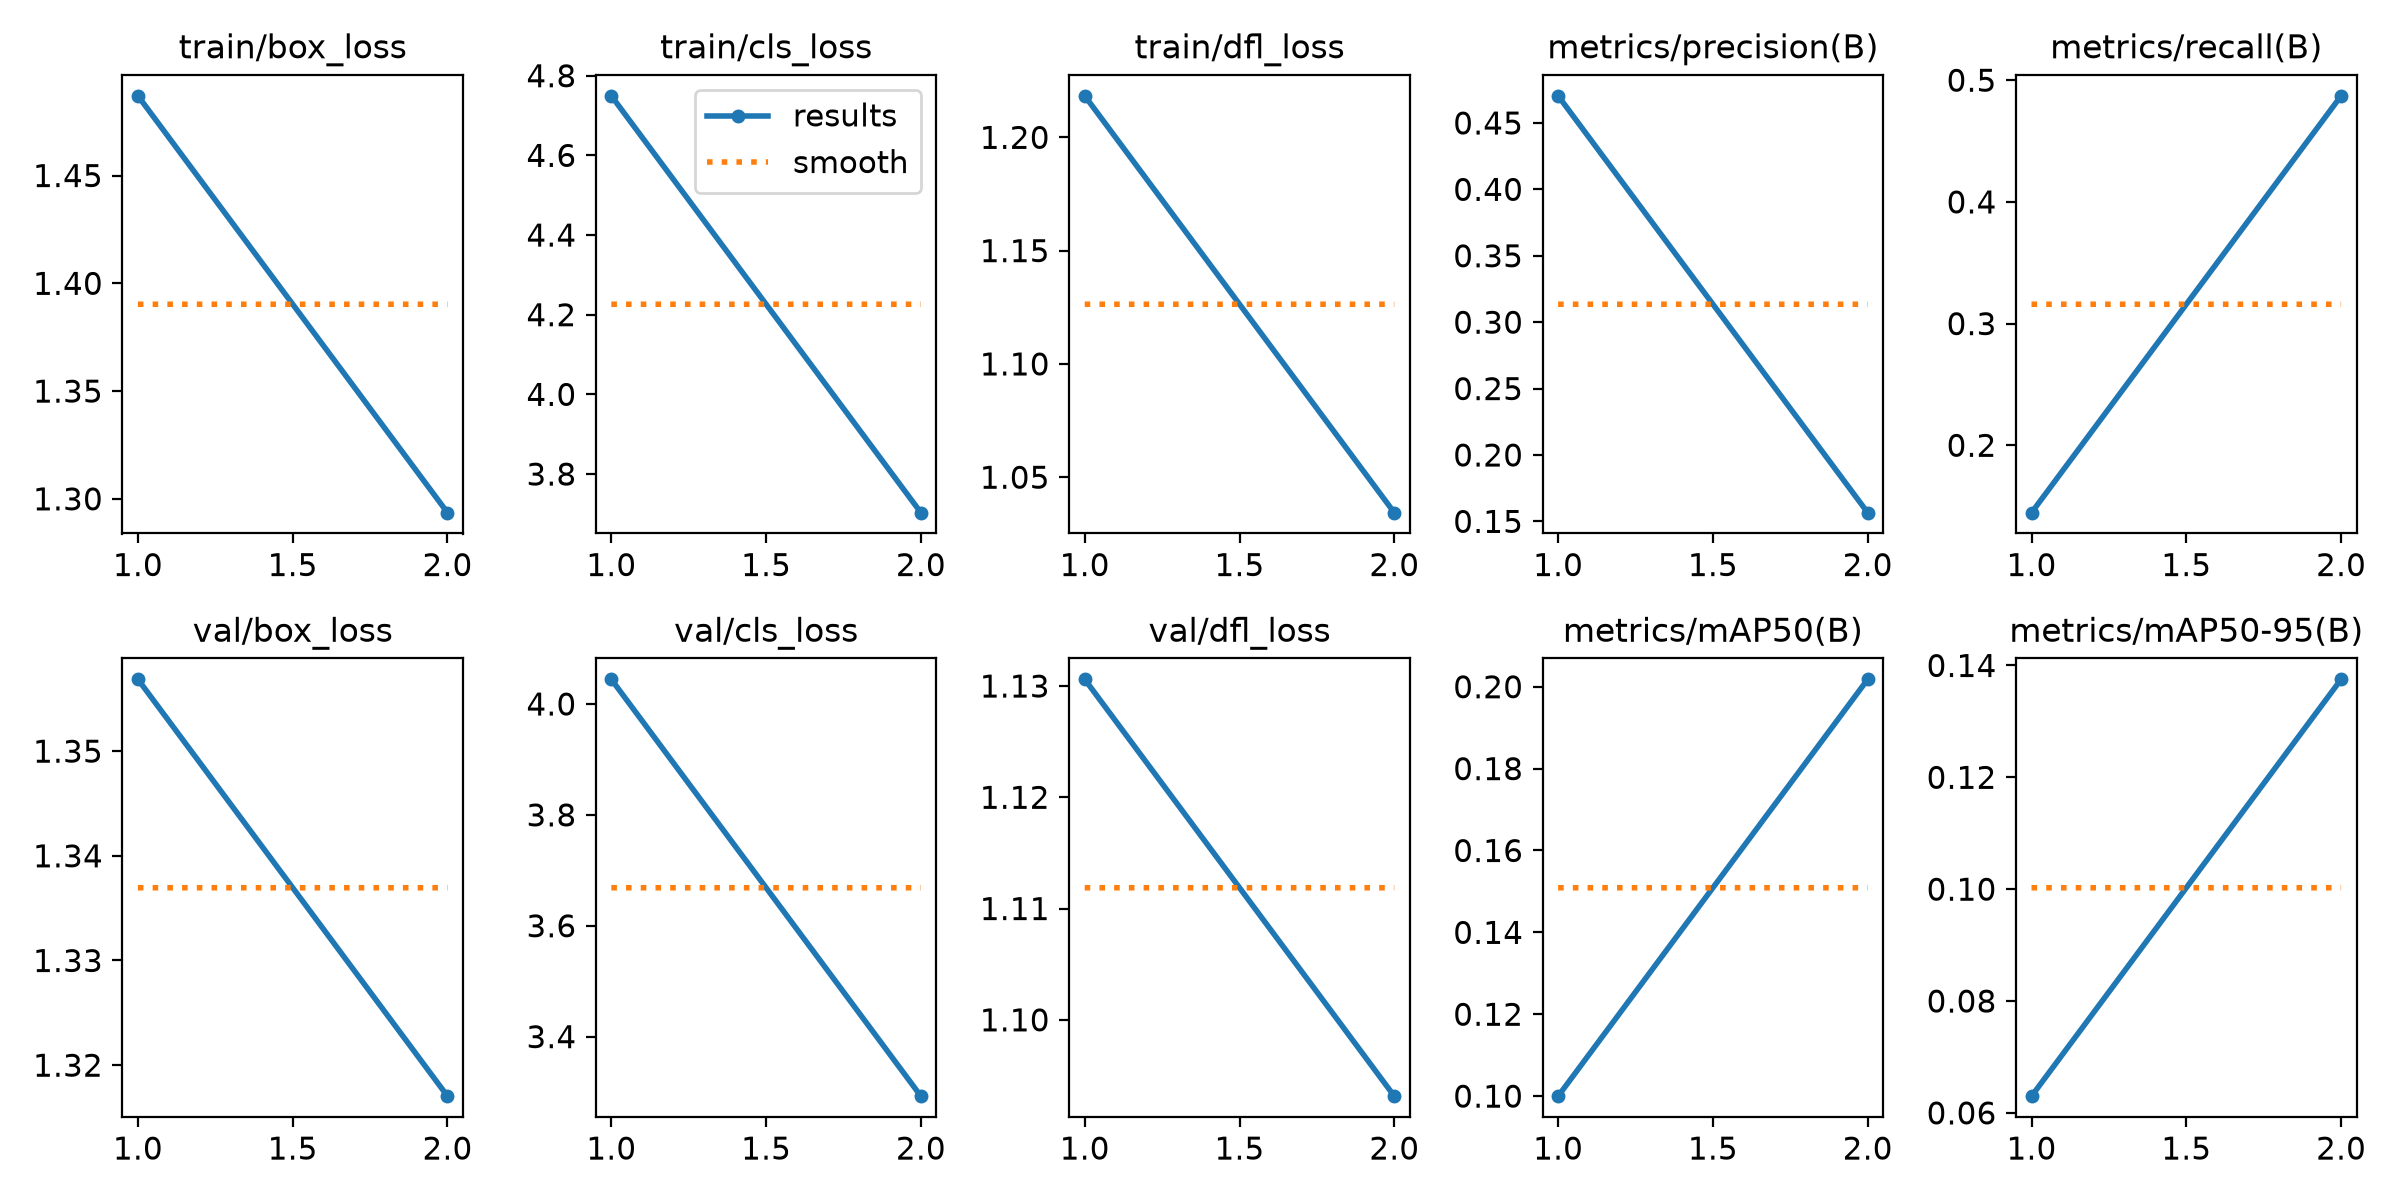

In [8]:
SMOKE_DIR = RUN_DIR / SMOKE_NAME
SMOKE_RESULTS = SMOKE_DIR / "results.csv"
SMOKE_LAST = SMOKE_DIR / "weights" / "last.pt"

print("Smoke directory:", SMOKE_DIR)
print("results.csv exists:", SMOKE_RESULTS.exists())
print("last.pt exists:", SMOKE_LAST.exists())

assert SMOKE_RESULTS.exists()
assert SMOKE_LAST.exists()

smoke_results_df = pd.read_csv(SMOKE_RESULTS)
display(smoke_results_df)

if (SMOKE_DIR / "results.png").exists():
    display(
        IPyImage(
            filename=str(SMOKE_DIR / "results.png"),
            width=900,
        )
    )


## 8. CPU 正式训练：10 类、每类 50 张、最多 40 轮

这次把数据量从 5 类 × 30 张增加到 10 类 × 50 张，正样本约 500 张，背景图 80 张。
由于你实际运行时 CPU 速度尚可，正式训练设置为最多 60 个 epoch。

`patience=12` 表示验证指标连续 12 个 epoch 没有改善时提前停止，因此实际轮数可能少于 60。

训练参数说明：

| 参数 | 值 | 说明 |
|---|---:|---|
| `imgsz` | 320 | 保持与现有 Demo 一致；降低输入尺寸可以明显减小 CPU 计算量 |
| `epochs` | 60 | 小规模数据集的上限轮数；配合早停 |
| `batch` | 4 | CPU 下较稳妥，避免内存峰值过高 |
| `workers` | 0 | Notebook 环境稳定优先 |
| `device` | `cpu` | 使用 CPU 训练 |
| `amp` | `False` | CPU 不使用自动混合精度 |
| `patience` | 12 | 验证集长期不提升时提前结束 |
| `mosaic` | 0.2 | 低概率拼接增强，增加场景变化 |
| `close_mosaic` | 10 | 最后 10 个 epoch 关闭 Mosaic，让训练收敛更平稳 |
| `degrees` | 5 | 小角度旋转增强 |
| `translate` | 0.1 | 平移增强比例 |
| `scale` | 0.3 | 缩放增强比例 |
| `fliplr` | 0.5 | 左右翻转概率；手势左右手通常都应支持 |
| `flipud` | 0 | 不做上下翻转，因为上下倒置不是自然手势变化 |
| `seed` | 42 | 保证采样和训练尽量可复现 |

这里重新从 `yolov8n.pt` 开始训练，而不是接着冒烟测试权重训练。
冒烟权重只是为了验证流程，正式训练应使用完整的训练配置。


In [9]:
FULL_NAME = "gesture10_demo_train_v1"

full_model = YOLO(str(MODEL_PATH))

full_model.train(
    data=str(DATA_YAML),
    imgsz=320,
    epochs=60,
    batch=4,
    workers=0,
    device="cpu",
    amp=False,
    cache=False,
    patience=12,
    mosaic=0.2,
    close_mosaic=10,
    mixup=0.0,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    shear=0.0,
    perspective=0.0,
    fliplr=0.5,
    flipud=0.0,
    seed=SEED,
    deterministic=True,
    project=str(RUN_DIR),
    name=FULL_NAME,
    exist_ok=True,
    plots=True,
)


Ultralytics 8.4.146 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core Ultra 5 125H)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/xx/gesture-training/data/yolo/gesture10_demo/data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/xx/gesture-training/yolov8n.pt, momentum=0.937, mosaic=0.2, multi_sca

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7069268060f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

## 9. 查看正式训练曲线和最佳权重

`best.pt` 是根据验证集指标保存的最佳权重，后续评估和推理都使用它。

观察曲线时重点关注：

- 训练损失是否总体下降；
- `metrics/mAP50(B)` 是否上升；
- 训练损失继续下降但验证 mAP 不再提升时，说明可能开始过拟合；
- 不同类别的效果还需要结合混淆矩阵查看。


Full training directory: /home/xx/gesture-training/runs/ultralytics/gesture10_demo_train_v1
best.pt exists: True


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
55,56,1402.56,0.63214,0.57039,0.84586,0.87456,0.81253,0.86818,0.66288,0.93266,0.94858,0.97326,0.000066,0.000066,0.000066
56,57,1427.32,0.65738,0.57802,0.85244,0.85219,0.84059,0.86540,0.65969,0.95819,0.97059,0.98368,0.000054,0.000054,0.000054
57,58,1450.92,0.64936,0.58514,0.86160,0.86127,0.82909,0.86310,0.66624,0.92982,0.93909,0.97654,0.000042,0.000042,0.000042
58,59,1474.27,0.61968,0.56025,0.84740,0.90524,0.80301,0.87260,0.67253,0.91440,0.92754,0.97164,0.000031,0.000031,0.000031
59,60,1498.03,0.60899,0.56323,0.84976,0.90099,0.81312,0.87548,0.67815,0.90891,0.91684,0.96735,0.000019,0.000019,0.000019


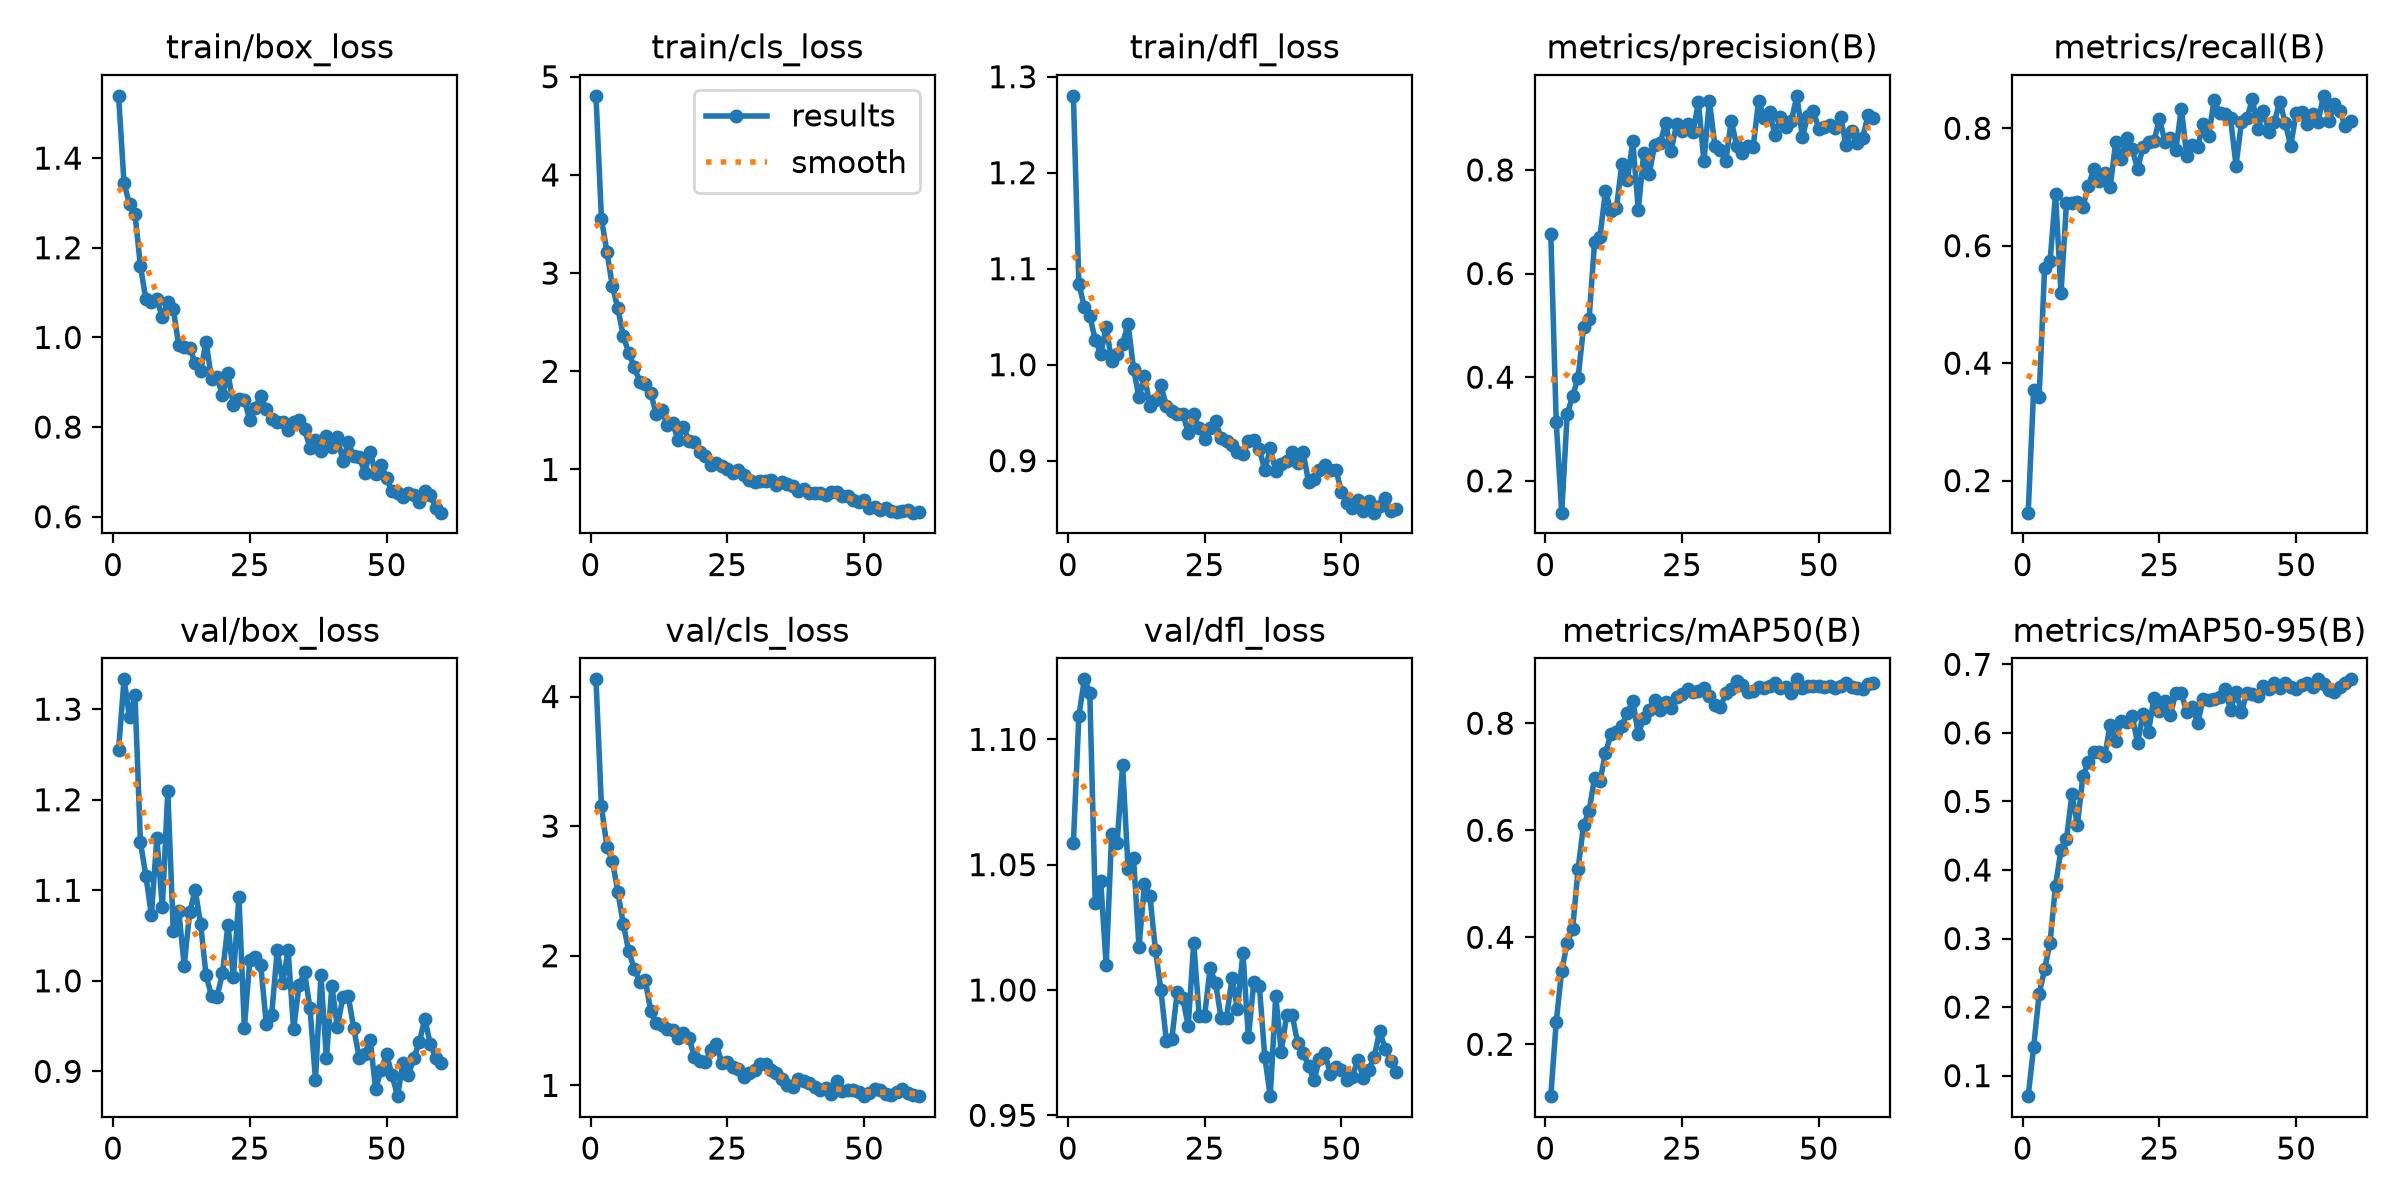

In [10]:
FULL_DIR = RUN_DIR / FULL_NAME
BEST_MODEL_PATH = FULL_DIR / "weights" / "best.pt"
FULL_RESULTS_PATH = FULL_DIR / "results.csv"

print("Full training directory:", FULL_DIR)
print("best.pt exists:", BEST_MODEL_PATH.exists())

assert BEST_MODEL_PATH.exists()
assert FULL_RESULTS_PATH.exists()

full_results_df = pd.read_csv(FULL_RESULTS_PATH)
display(full_results_df.tail())

if (FULL_DIR / "results.png").exists():
    display(
        IPyImage(
            filename=str(FULL_DIR / "results.png"),
            width=900,
        )
    )


## 10. 在验证集和测试集上评估

验证集用于训练过程中选择最佳权重；测试集只在最后使用，用于观察模型在留出数据上的表现。

主要指标含义：

- `precision`：预测为手势的框中，有多少是正确的；
- `recall`：真实手势目标中，有多少被检测出来；
- `mAP50`：IoU=0.50 时的平均精度；
- `mAP50-95`：IoU 从 0.50 到 0.95 多个阈值下的平均精度，更严格。

由于本 Notebook 仍是小规模子集，测试指标会有明显波动，主要用于学习和排查流程。


In [11]:
best_model = YOLO(str(BEST_MODEL_PATH))


def evaluate_split(split, run_name):
    return best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=320,
        batch=4,
        workers=0,
        device="cpu",
        plots=True,
        project=str(RUN_DIR),
        name=run_name,
        exist_ok=True,
        verbose=False,
    )


val_metrics = evaluate_split(
    split="val",
    run_name="gesture10_demo_val_v1",
)

test_metrics = evaluate_split(
    split="test",
    run_name="gesture10_demo_test_v1",
)


metric_rows = []

for split_name, metrics in [
    ("val", val_metrics),
    ("test", test_metrics),
]:
    row = {"split": split_name}

    for key, value in metrics.results_dict.items():
        if np.isscalar(value):
            row[key] = float(value)

    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)


Ultralytics 8.4.146 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core Ultra 5 125H)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3190.5±932.3 MB/s, size: 129.5 KB)
val: Scanning /home/xx/gesture-training/data/yolo/gesture10_demo/labels/val.cache... 87 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 36.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 13.9it/s 1.6s0.1s
                   all         87         76      0.908      0.807      0.874      0.675
Speed: 0.1ms preprocess, 13.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/xx/gesture-training/runs/ultralytics/gesture10_demo_val_v1
Ultralytics 8.4.146 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core Ultra 5 125H)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0

,split,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
0,val,0.907607,0.806727,0.874445,0.674916,0.674916
1,test,0.945120,0.851803,0.949916,0.758691,0.758691


## 11. 查看混淆矩阵和 PR/F1 曲线

混淆矩阵用于观察哪些手势容易互相误判，例如外观相近的类别。

- 对角线越明显，代表正确分类越多；
- 某个类别经常被预测成另一个类别，说明需要更多样本或更有区分度的数据；
- PR 曲线和 F1 曲线可以帮助理解置信度阈值的影响。


confusion_matrix.png


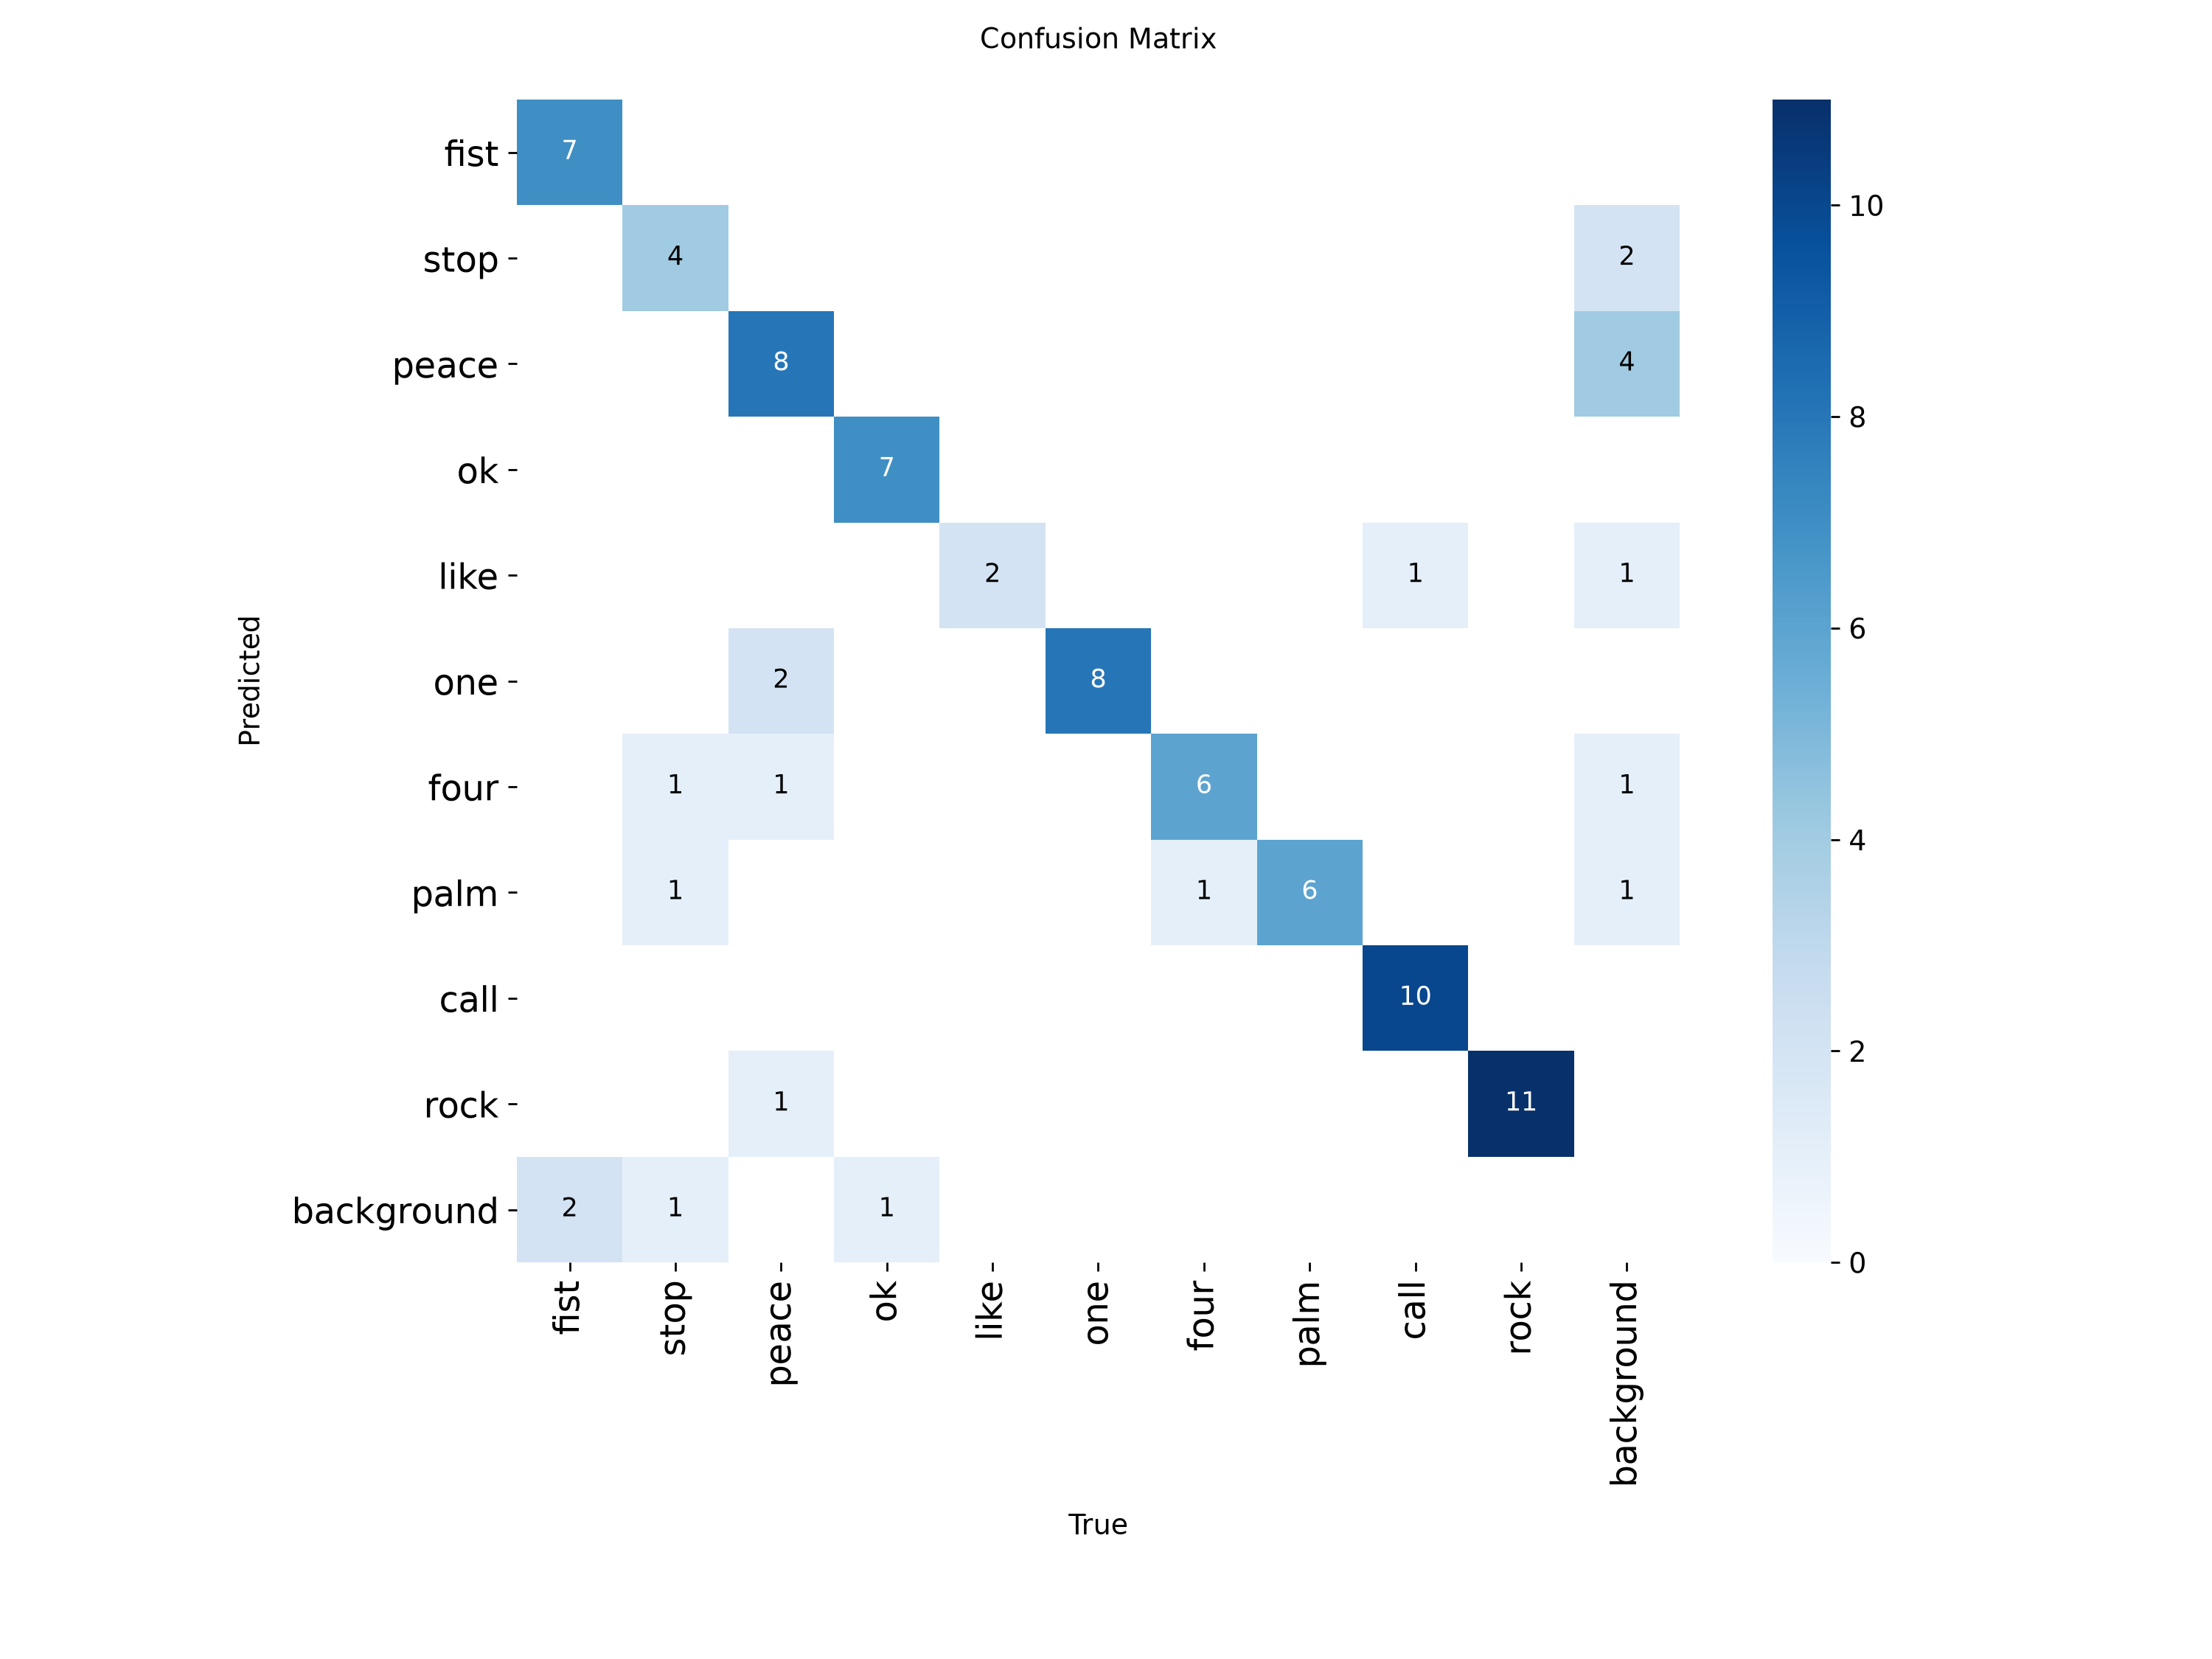

confusion_matrix_normalized.png


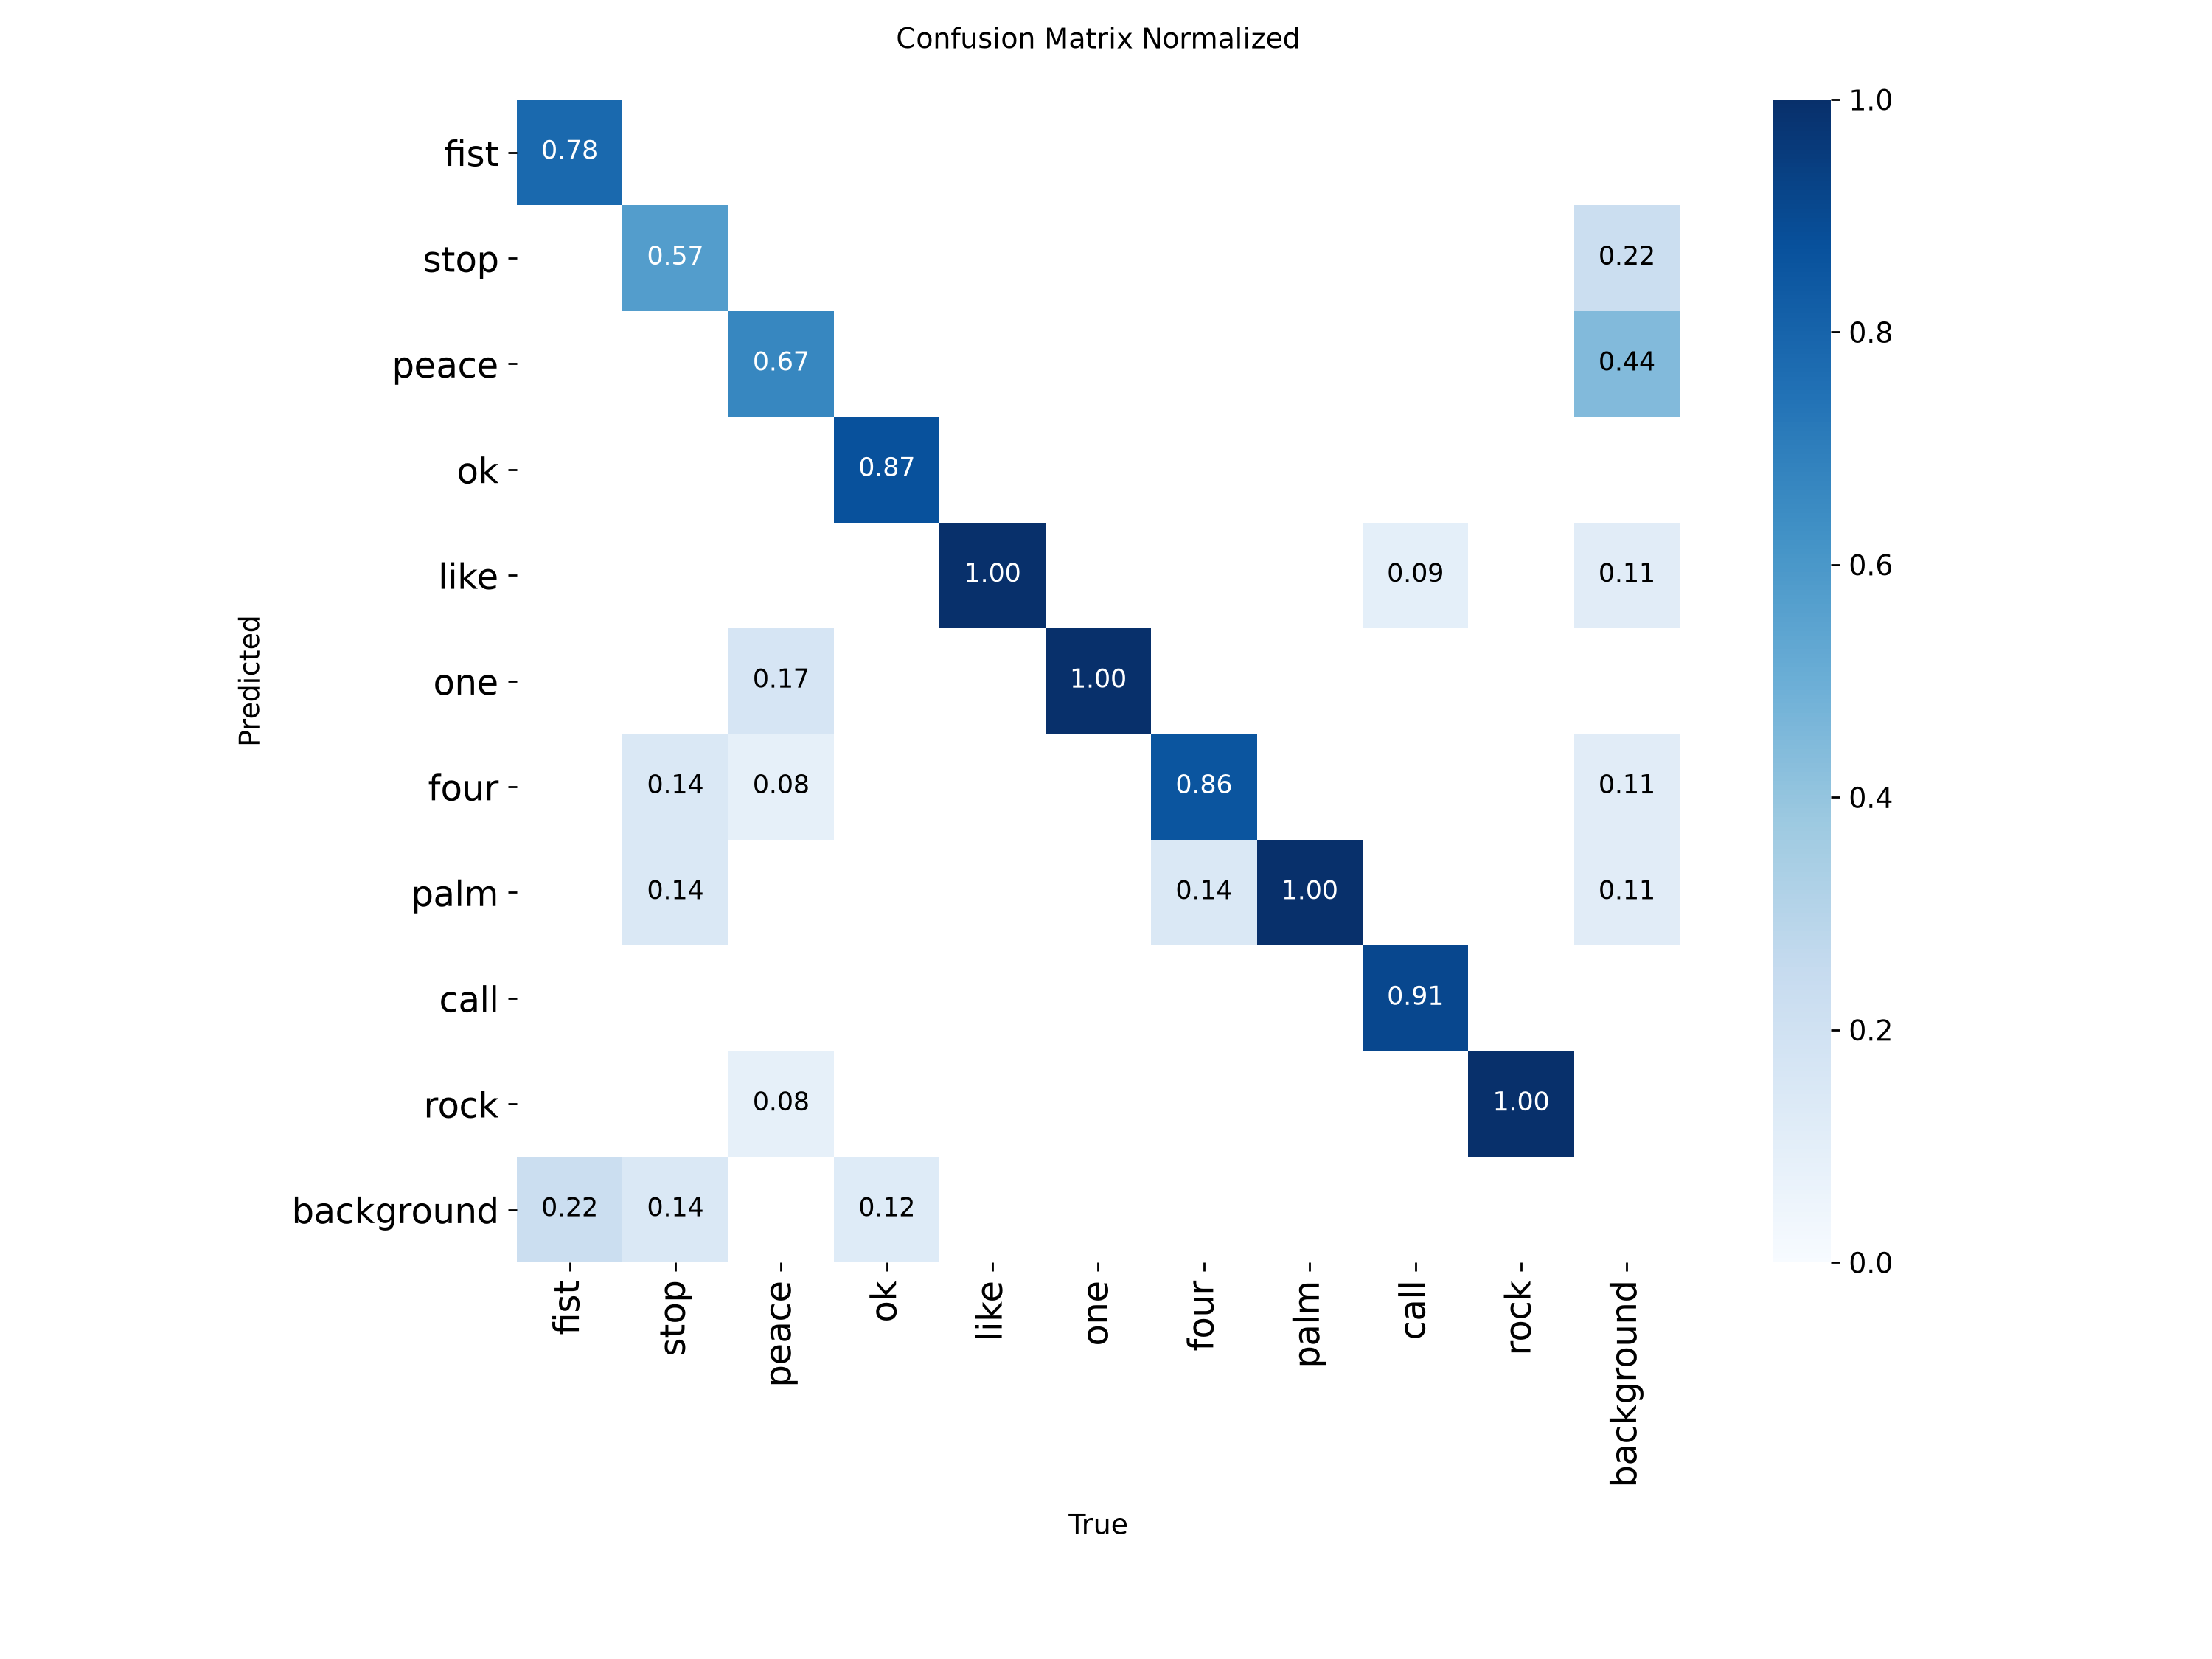

BoxPR_curve.png


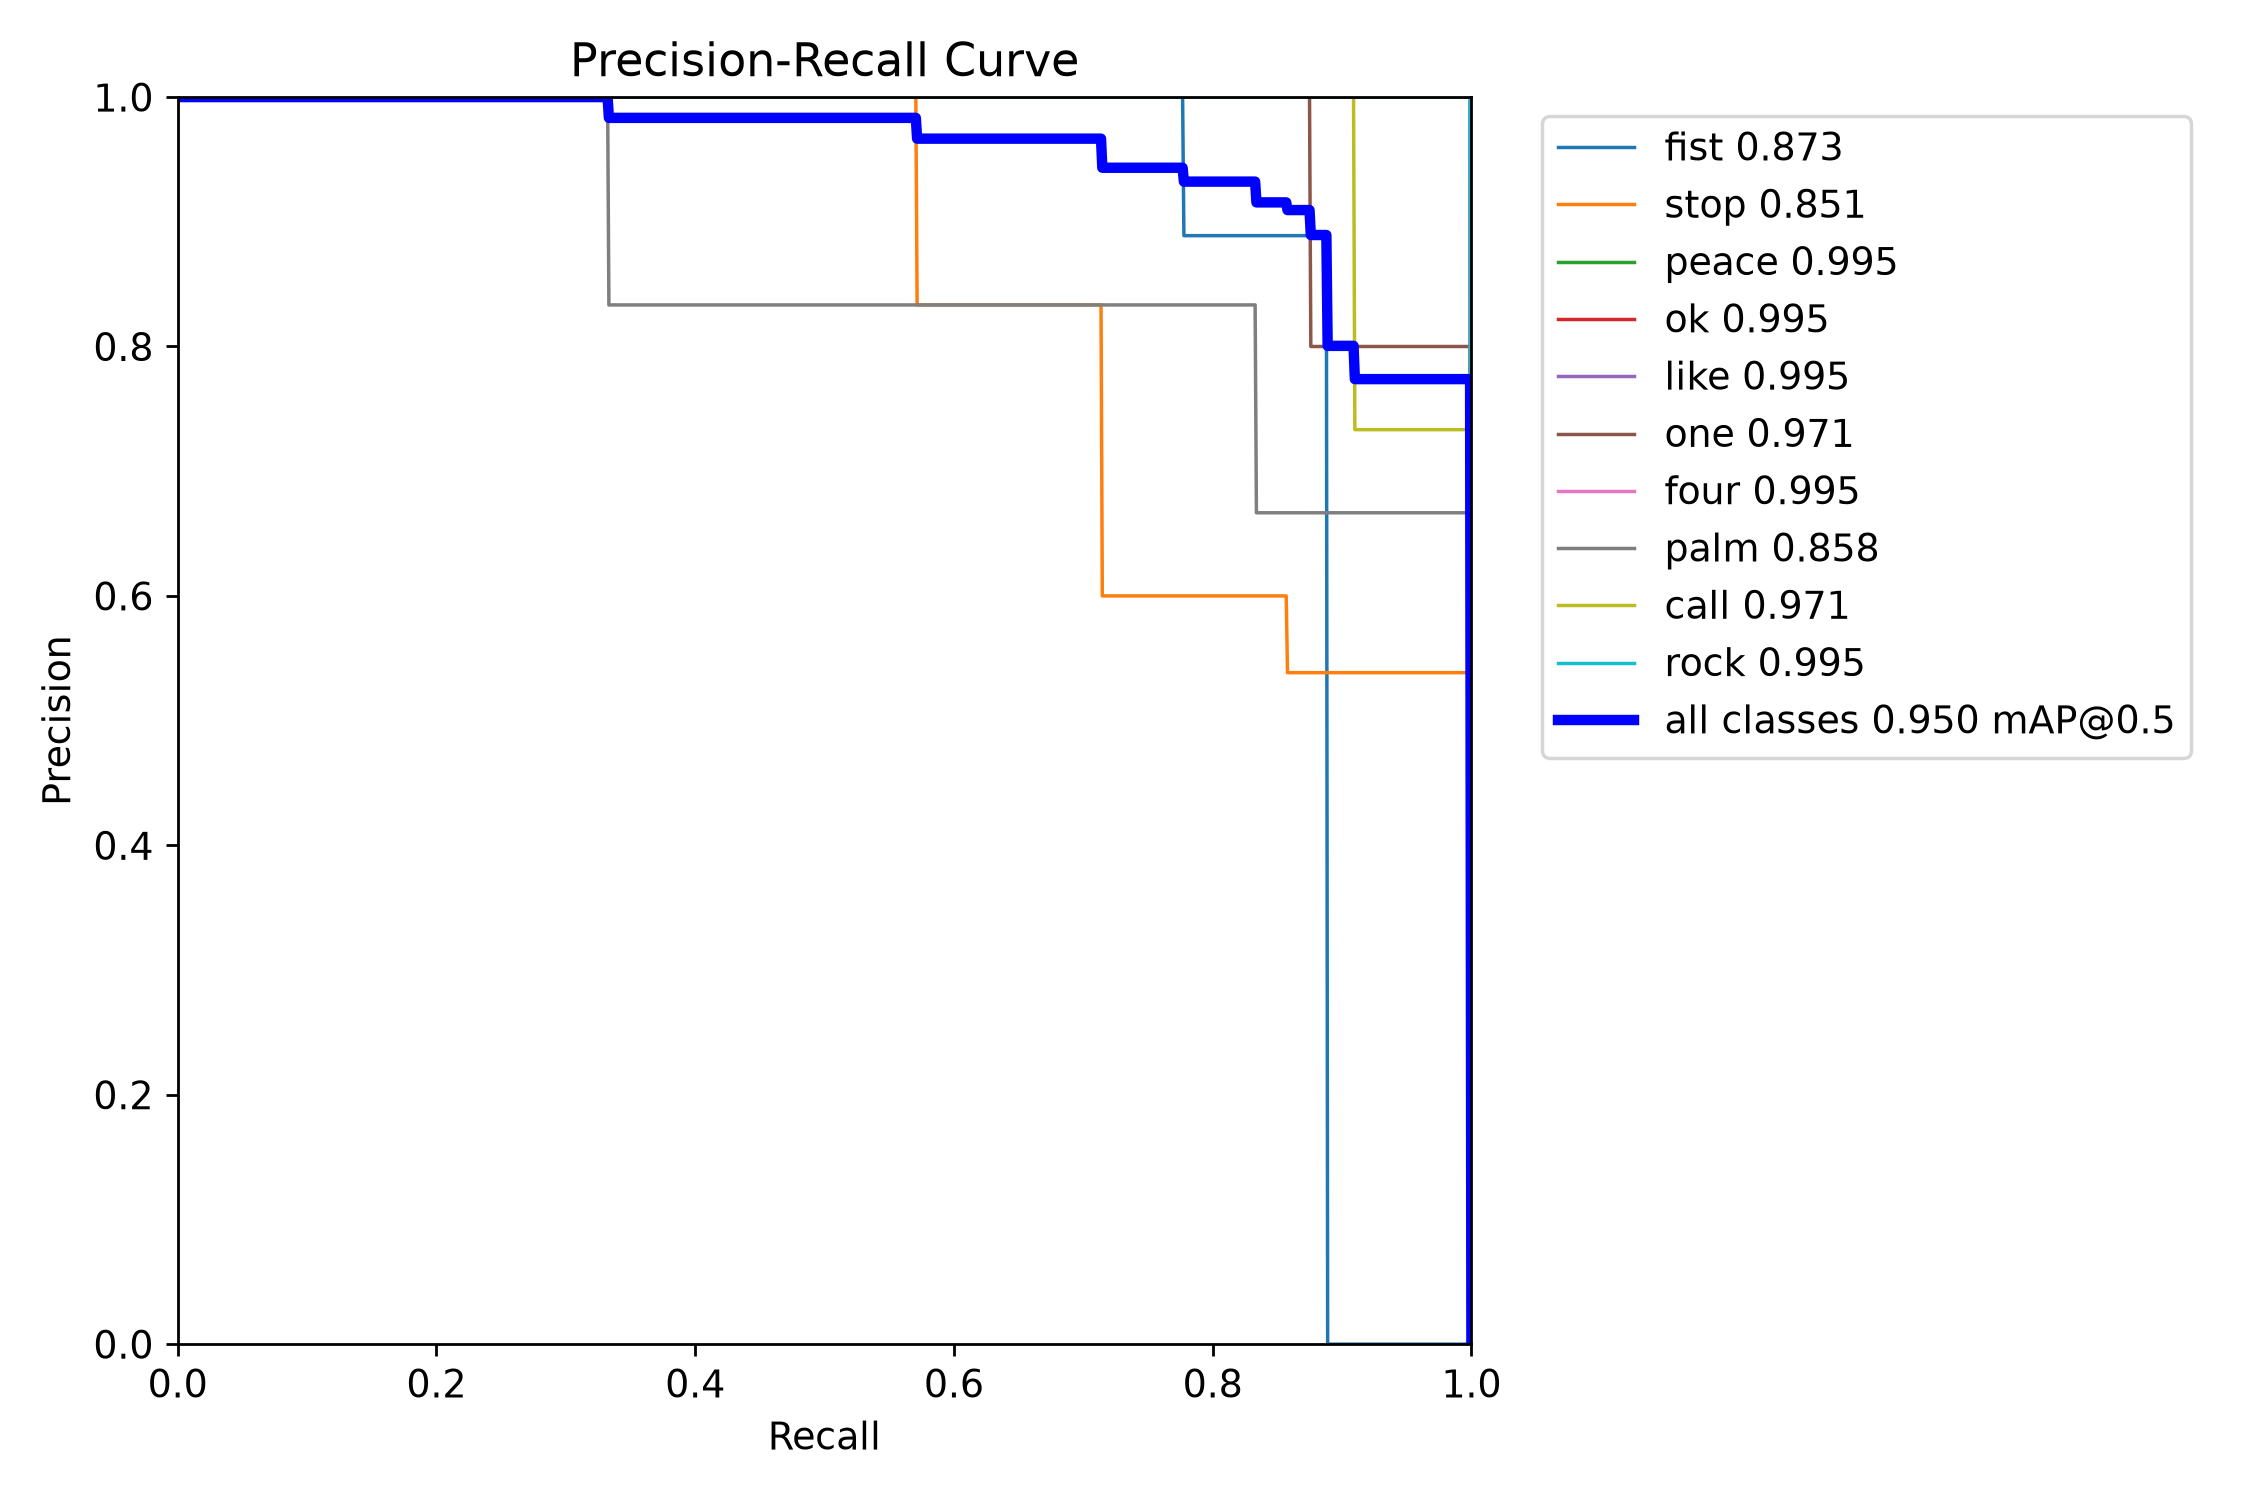

BoxF1_curve.png


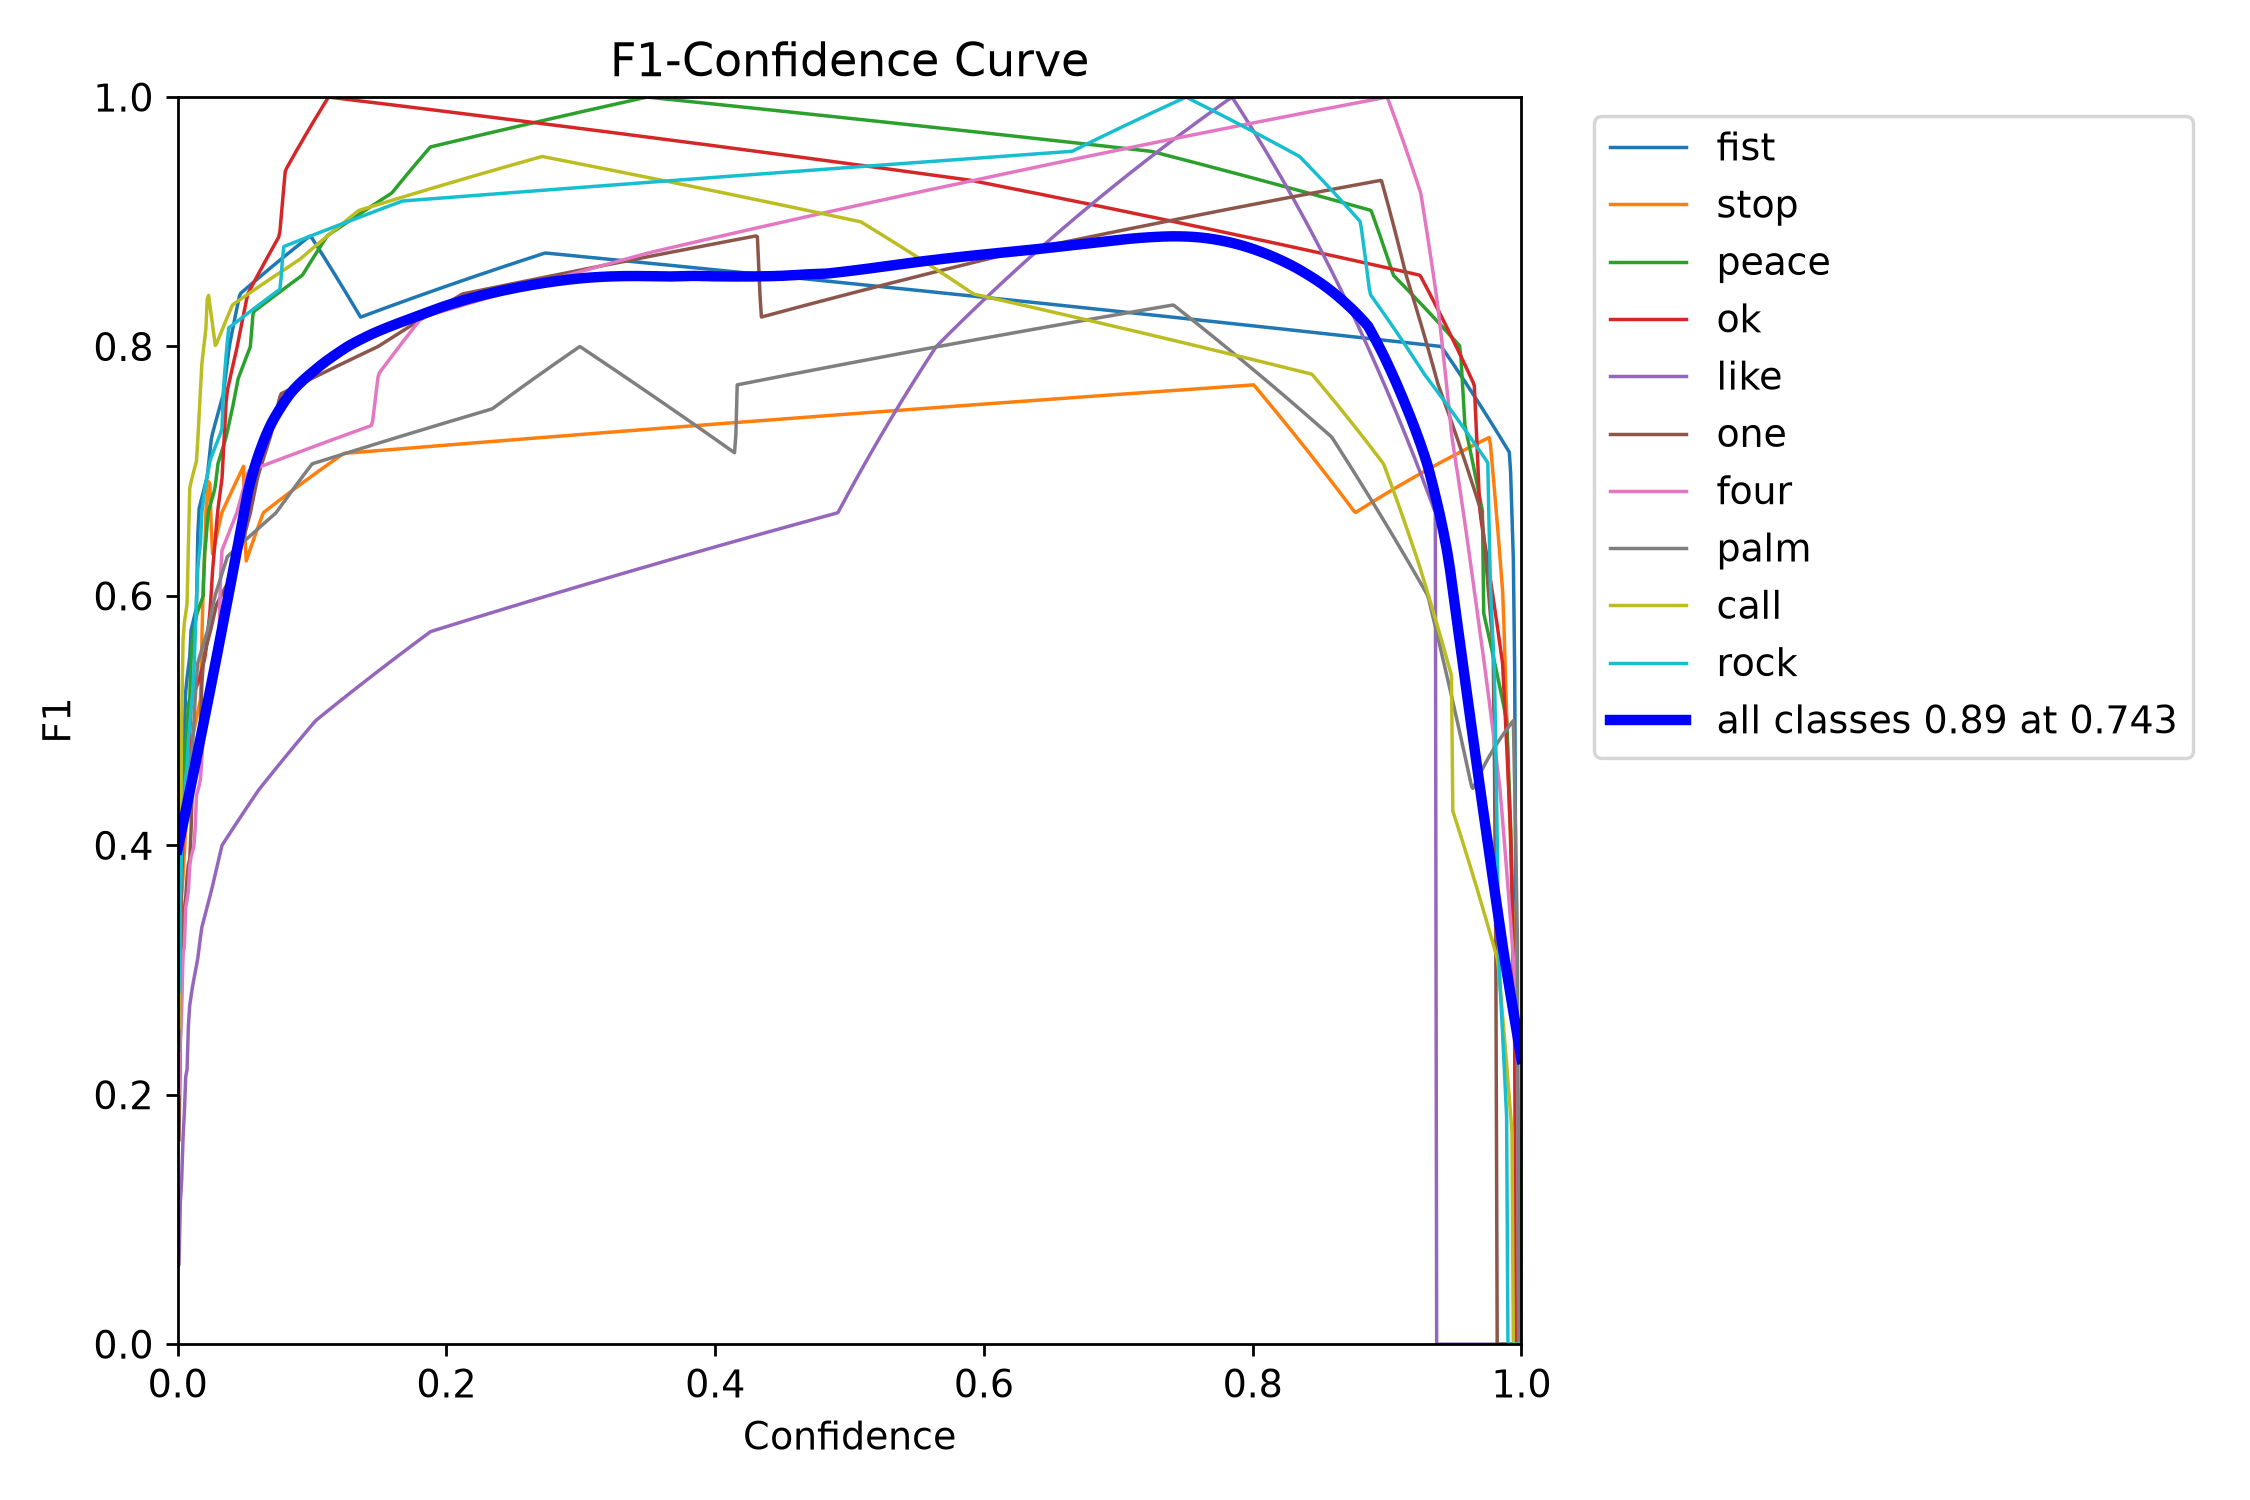

In [12]:
TEST_EVAL_DIR = RUN_DIR / "gesture10_demo_test_v1"

for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
]:
    path = TEST_EVAL_DIR / filename

    if path.exists():
        print(filename)
        display(
            IPyImage(
                filename=str(path),
                width=750,
            )
        )


## 12. 最终推理验证

这里从 test 集随机取最多 12 张图片做推理。它们没有参与训练，因此可以作为一个简单的最终检查。

推理参数：

- `conf=0.25`：只保留置信度不低于 0.25 的预测框；阈值越高，预测更保守；
- `iou=0.45`：NMS 的 IoU 阈值，用于去除重复框；
- `save=True`：保存画框后的图片；
- `save_txt=True`：同时保存预测标签；
- `save_conf=True`：在预测标签中保存置信度。

注意：推理时使用的是模型预测结果，不能把真实标签文件当作模型输出。
后面的 Cell 会同时打印 ground truth 和 prediction，帮助比较两者。


In [13]:
PREDICT_NAME = "gesture10_demo_predictions_v1"
PREDICT_DIR = RUN_DIR / PREDICT_NAME

test_image_paths = sorted(
    (DATASET_DIR / "images" / "test").glob("*.jpg")
)

rng = random.Random(SEED + 1)
predict_paths = rng.sample(
    test_image_paths,
    min(12, len(test_image_paths)),
)

print("Prediction inputs:")
for path in predict_paths:
    print(path.name)


prediction_results = best_model.predict(
    source=[str(path) for path in predict_paths],
    imgsz=320,
    conf=0.25,
    iou=0.45,
    device="cpu",
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(RUN_DIR),
    name=PREDICT_NAME,
    exist_ok=True,
    verbose=False,
)

print("Prediction output:", PREDICT_DIR)


Prediction inputs:
call_5f297bba-c50e-4798-96ac-4a4c5abf58ae.jpg
no_gesture_c692db85-25df-4c96-85cd-fc1f1ac92513.jpg
stop_e1904333-13a9-474f-bb98-0e9cef7c270a.jpg
fist_a0b65f81-c13e-4719-bf04-2b9b540209a3.jpg
palm_ffa6b771-c814-45c5-9b2e-3d1f74694fd0.jpg
one_4355640d-40b9-4362-b748-d19bfd4122c0.jpg
stop_8485635f-bec5-469e-ad0d-d895aa9557a7.jpg
fist_48648962-ae06-4c05-8ec2-c7432b97fe5c.jpg
palm_e56372c3-bd08-478f-a682-19e6a6cb7d19.jpg
rock_9c53e95f-c37b-4a81-b58e-57ace794fb5e.jpg
peace_4809b404-7015-4e1d-84ce-e60ff9b394fe.jpg
rock_b29d6729-295f-4f9e-9128-01a278225988.jpg
Results saved to /home/xx/gesture-training/runs/ultralytics/gesture10_demo_predictions_v1
11 labels saved to /home/xx/gesture-training/runs/ultralytics/gesture10_demo_predictions_v1/labels
Prediction output: /home/xx/gesture-training/runs/ultralytics/gesture10_demo_predictions_v1


## 13. 查看推理图片

保存的图片中会显示模型预测出的类别、置信度和边界框。

对于 `no_gesture` 背景图，理想情况是图片上没有预测框；如果背景图上出现高置信度手势框，
说明模型存在误检，需要增加背景样本或调整置信度阈值。


call_5f297bba-c50e-4798-96ac-4a4c5abf58ae.jpg


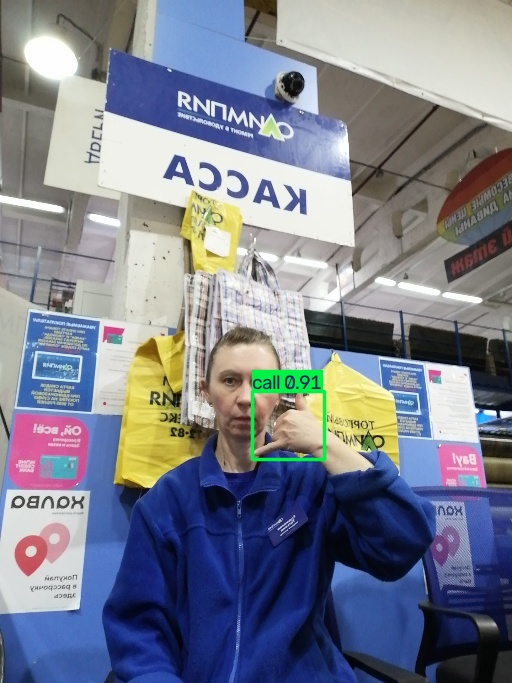

fist_48648962-ae06-4c05-8ec2-c7432b97fe5c.jpg


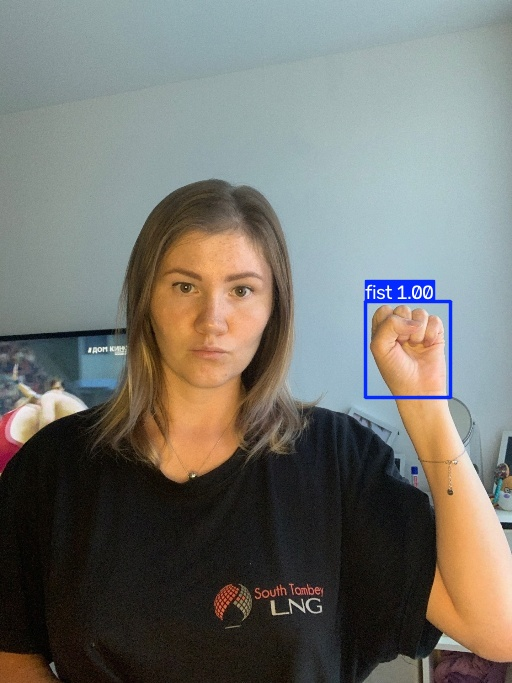

fist_a0b65f81-c13e-4719-bf04-2b9b540209a3.jpg


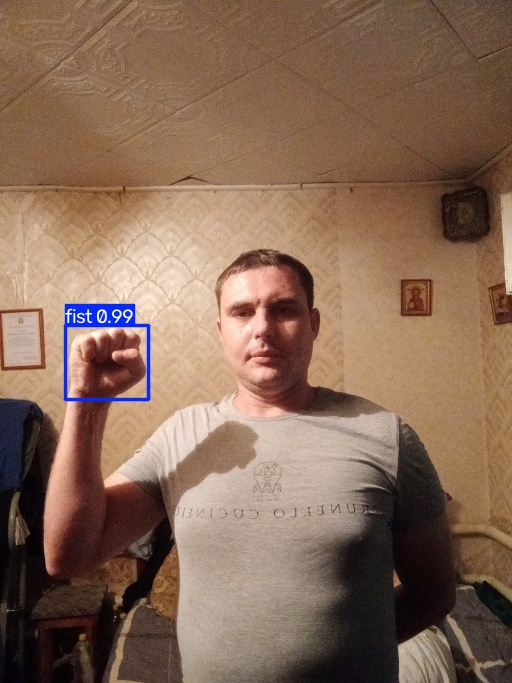

no_gesture_c692db85-25df-4c96-85cd-fc1f1ac92513.jpg


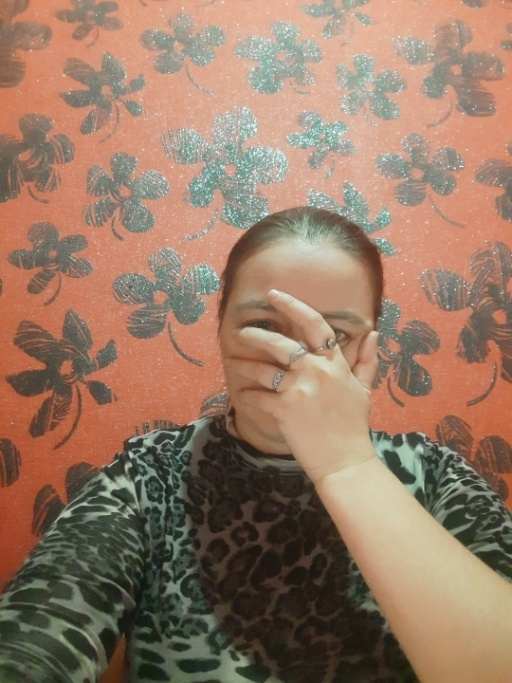

one_4355640d-40b9-4362-b748-d19bfd4122c0.jpg


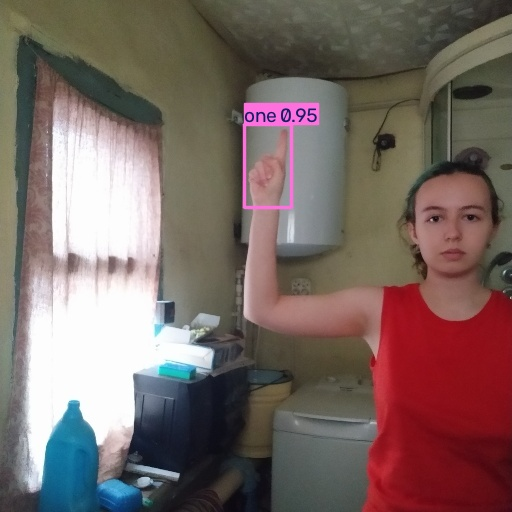

palm_e56372c3-bd08-478f-a682-19e6a6cb7d19.jpg


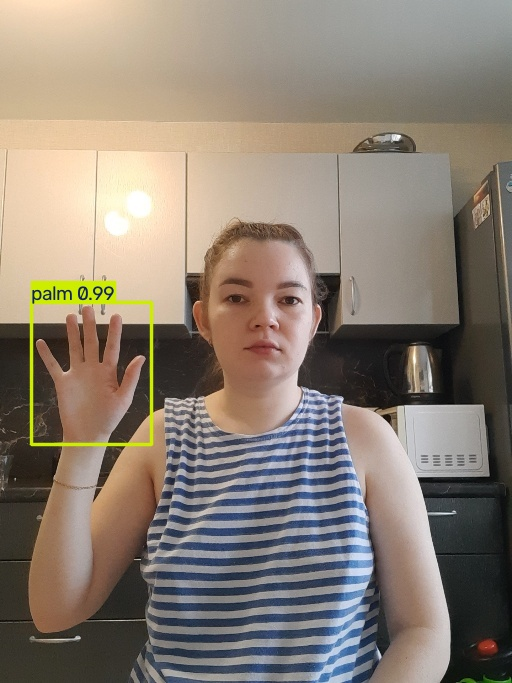

palm_ffa6b771-c814-45c5-9b2e-3d1f74694fd0.jpg


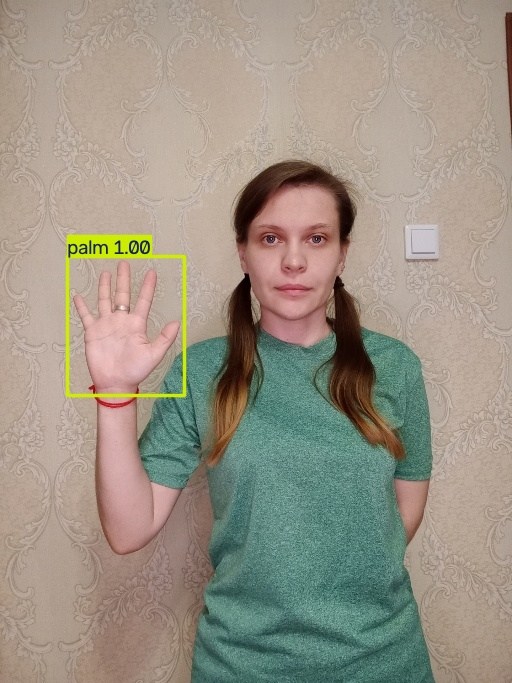

peace_4809b404-7015-4e1d-84ce-e60ff9b394fe.jpg


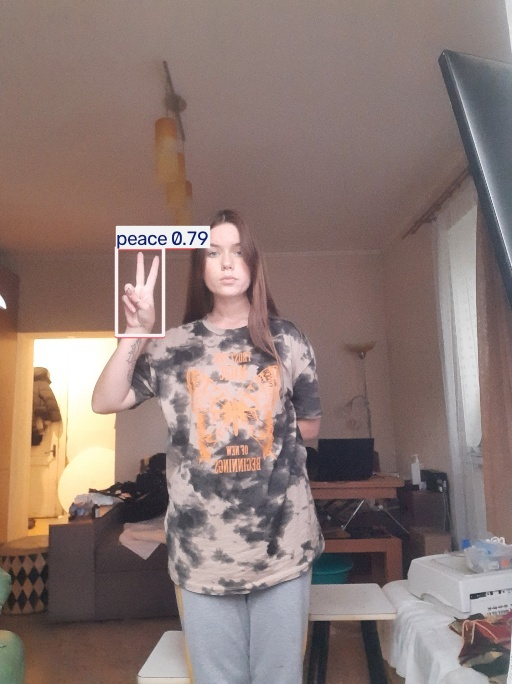

rock_9c53e95f-c37b-4a81-b58e-57ace794fb5e.jpg


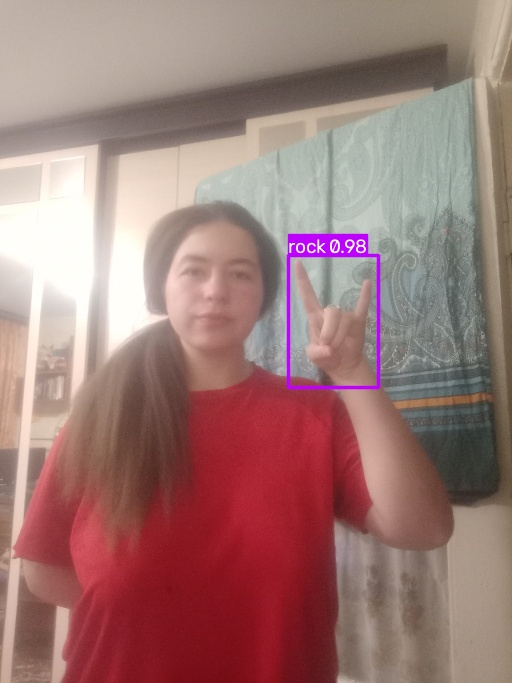

rock_b29d6729-295f-4f9e-9128-01a278225988.jpg


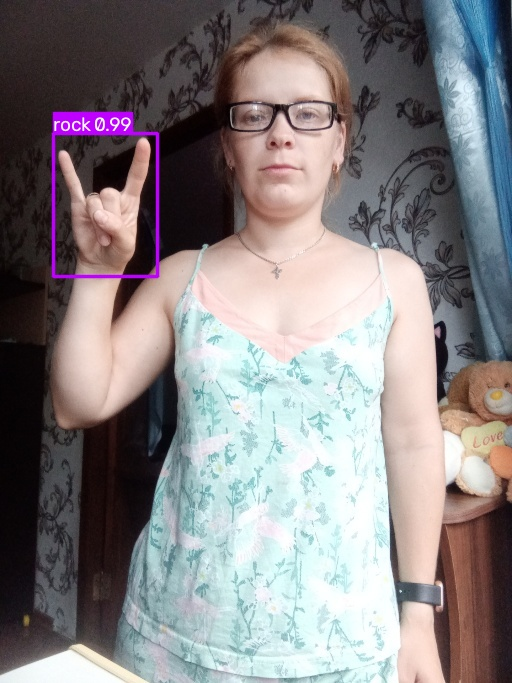

stop_8485635f-bec5-469e-ad0d-d895aa9557a7.jpg


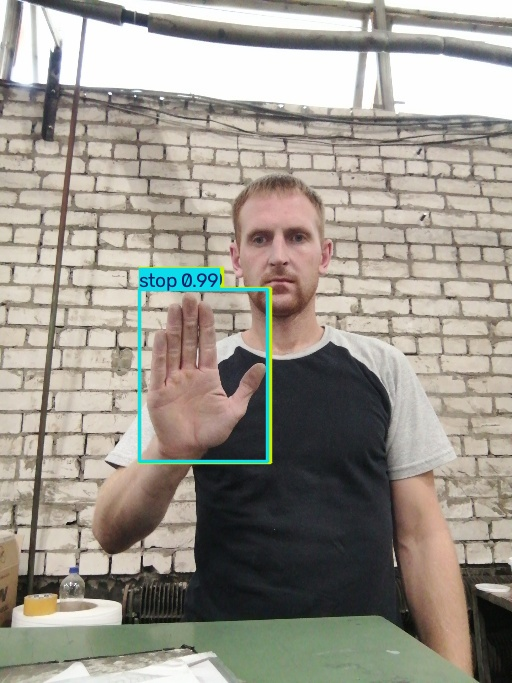

stop_e1904333-13a9-474f-bb98-0e9cef7c270a.jpg


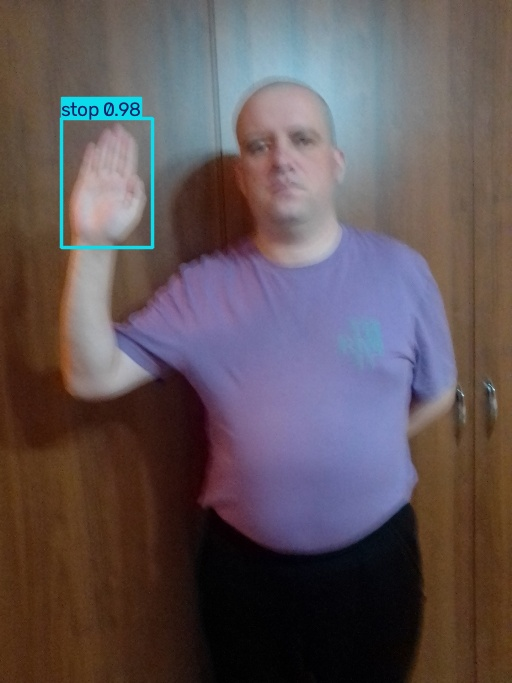

In [14]:
saved_prediction_images = sorted(
    path
    for path in PREDICT_DIR.glob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

for path in saved_prediction_images:
    print(path.name)
    display(
        IPyImage(
            filename=str(path),
            width=650,
        )
    )


## 14. 对比真实标签和模型预测

最后把测试集真实标签和推理结果按图片逐一打印。

这一步可以帮助判断错误来自哪里：

- 没有预测框：可能是置信度阈值太高，或模型没有学会该类别；
- 类别预测错误：可能是类别外观相似，或样本数量不足；
- 框位置明显偏移：需要回到标签可视化阶段检查数据转换。


In [15]:
def get_ground_truth_names(image_path):
    label_path = (
        DATASET_DIR / "labels" / "test" /
        image_path.with_suffix(".txt").name
    )

    text = label_path.read_text(encoding="utf-8").strip()

    if not text:
        return []

    names = []

    for line in text.splitlines():
        class_id = int(line.split()[0])
        names.append(CLASS_NAMES[class_id])

    return names


for image_path, result in zip(predict_paths, prediction_results):
    ground_truth = get_ground_truth_names(image_path)
    predictions = []

    if result.boxes is not None:
        for class_id, confidence in zip(
            result.boxes.cls.tolist(),
            result.boxes.conf.tolist(),
        ):
            predictions.append(
                (
                    CLASS_NAMES[int(class_id)],
                    round(float(confidence), 3),
                )
            )

    print(f"\n{image_path.name}")
    print("ground truth:", ground_truth or ["background"])
    print("prediction:", predictions or ["no detection"])



call_5f297bba-c50e-4798-96ac-4a4c5abf58ae.jpg
ground truth: ['call']
prediction: [('call', 0.905)]

no_gesture_c692db85-25df-4c96-85cd-fc1f1ac92513.jpg
ground truth: ['background']
prediction: ['no detection']

stop_e1904333-13a9-474f-bb98-0e9cef7c270a.jpg
ground truth: ['stop']
prediction: [('stop', 0.977)]

fist_a0b65f81-c13e-4719-bf04-2b9b540209a3.jpg
ground truth: ['fist']
prediction: [('fist', 0.988)]

palm_ffa6b771-c814-45c5-9b2e-3d1f74694fd0.jpg
ground truth: ['palm']
prediction: [('palm', 0.997)]

one_4355640d-40b9-4362-b748-d19bfd4122c0.jpg
ground truth: ['one']
prediction: [('one', 0.951)]

stop_8485635f-bec5-469e-ad0d-d895aa9557a7.jpg
ground truth: ['stop']
prediction: [('stop', 0.991), ('palm', 0.303)]

fist_48648962-ae06-4c05-8ec2-c7432b97fe5c.jpg
ground truth: ['fist']
prediction: [('fist', 0.996)]

palm_e56372c3-bd08-478f-a682-19e6a6cb7d19.jpg
ground truth: ['palm']
prediction: [('palm', 0.993)]

rock_9c53e95f-c37b-4a81-b58e-57ace794fb5e.jpg
ground truth: ['rock']
predi

## 15. 以标注图片形式展示最终推理结果

下面按照前面标签可视化的方式，把模型预测的边界框、类别名称和置信度直接绘制到图片上。

绿色框表示模型当前保留下来的预测框；标题对应输入图片名称。
这一步比只看数值更直观，适合检查框的位置、类别和背景误检。


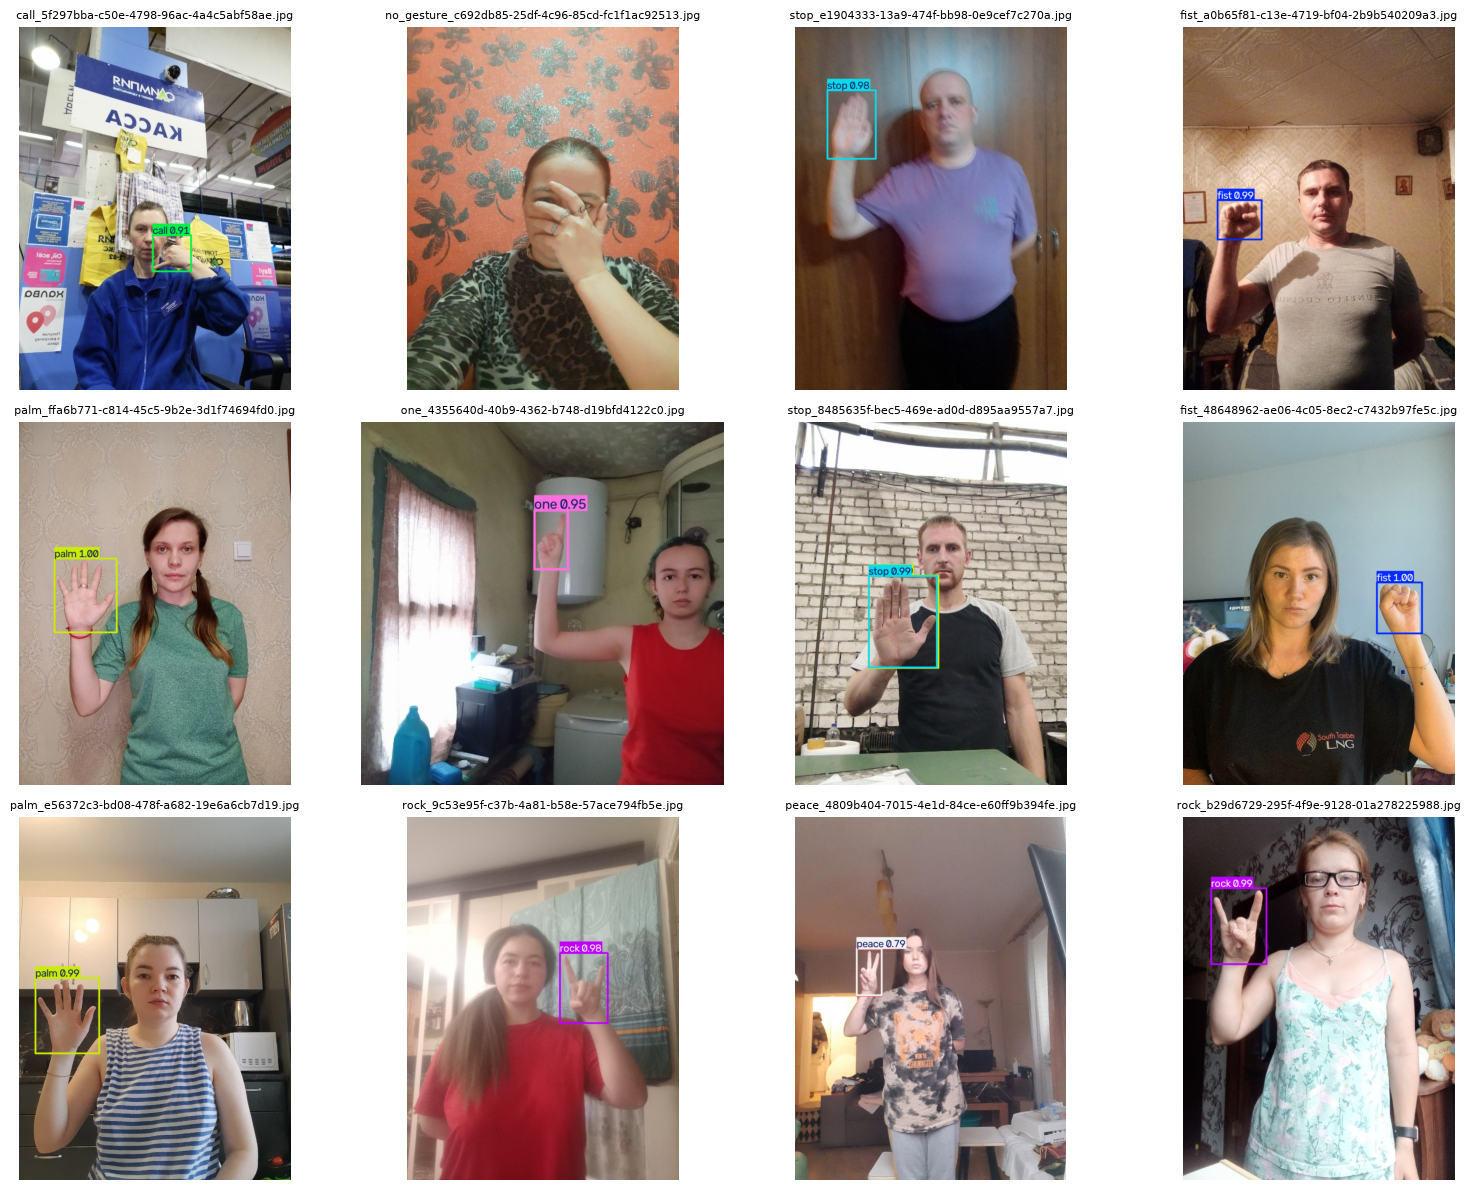

In [16]:
def show_prediction_results(results, image_paths, columns=4):
    count = len(results)
    rows = int(np.ceil(count / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, 4 * rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, result, image_path in zip(axes, results, image_paths):
        # Ultralytics 的 plot() 返回 BGR 图像，Matplotlib 需要 RGB。
        plotted = result.plot(
            conf=True,
            labels=True,
            boxes=True,
        )
        ax.imshow(plotted[..., ::-1])
        ax.set_title(image_path.name, fontsize=8)
        ax.axis("off")

    for ax in axes[count:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_prediction_results(
    prediction_results,
    predict_paths,
    columns=4,
)


## 16. 本次 Demo 的结论和下一步

本次训练是一个可重复的十类 CPU Demo，不是最终生产模型。后续如果要提升效果，可以按下面顺序扩展：

1. 将 `MAX_PER_CLASS` 从 50 增加到 80 或 100；
2. 保持按 `user_id` 划分，重新生成数据集；
3. 将 `epochs` 提高到 60~80，并观察 `patience` 是否提前停止；
4. 查看混淆矩阵，对误判严重的类别补充更多样本；
5. 将 `imgsz` 从 320 提高到 416 或 640，但 CPU 训练时间会明显增加；
6. 最后再考虑导出 ONNX 或 LiteRT/TFLite。

当前生成的主要文件位置：

```text
data/yolo/gesture10_demo/
runs/ultralytics/gesture10_demo_smoke_v1/
runs/ultralytics/gesture10_demo_train_v1/
runs/ultralytics/gesture10_demo_test_v1/
runs/ultralytics/gesture10_demo_predictions_v1/
```
